In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import sys
import importlib
import shutil
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# PROJECT MODULES
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.experiments.event_training_comparison as etc
importlib.reload(etc)

print("Project root:", project_root)
print("Project root exists:", project_root.exists())

Project root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg
Project root exists: True


In [3]:
# ============================================================
# PATHS
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

rbatheta_base_path = Path(
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together"
)

results_base_dir = (
    project_root
    / "results"
    / "final_event_training_experiment"
)

print("Database path:", db_path)
print("Database exists:", db_path.exists())

print("\nrbaTheta base path:", rbatheta_base_path)
print("rbaTheta path exists:", rbatheta_base_path.exists())

print("\nResults base directory:", results_base_dir)

Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Database exists: True

rbaTheta base path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together
rbaTheta path exists: True

Results base directory: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\final_event_training_experiment


In [4]:
# ============================================================
# FINAL EXPERIMENT CONFIGURATION
# ============================================================

# Two zones selected according to historical price volatility.
# Adjust only if your volatility analysis selected different zones.
selected_zones = [
    "NO2",  # high-volatility zone
    "NO4",  # low-volatility zone
]

calibration_configs = [
    {
        "calibration_name": "cal_2020",
        "calibration_start": "2020-01-01",
        "calibration_end": "2020-12-31",
    },
    {
        "calibration_name": "cal_2020_2021",
        "calibration_start": "2020-01-01",
        "calibration_end": "2021-12-31",
    },
    {
        "calibration_name": "cal_2020_2022",
        "calibration_start": "2020-01-01",
        "calibration_end": "2022-12-31",
    },
]

train_start = "2023-01-01"
train_end = "2023-12-31"

test_weeks = [
    {
        "test_name": "winter_january",
        "test_start": "2024-01-15",
        "test_end": "2024-01-21",
    },
    {
        "test_name": "spring_april",
        "test_start": "2024-04-10",
        "test_end": "2024-04-16",
    },
    {
        "test_name": "summer_june",
        "test_start": "2024-06-24",
        "test_end": "2024-06-30",
    },
    {
        "test_name": "autumn_september",
        "test_start": "2024-09-16",
        "test_end": "2024-09-22",
    },
    {
        "test_name": "winter_december",
        "test_start": "2024-12-02",
        "test_end": "2024-12-08",
    },
]

target_horizon = 1

test_start = min(week["test_start"] for week in test_weeks)
test_end = max(week["test_end"] for week in test_weeks)

global_start = min(
    [cfg["calibration_start"] for cfg in calibration_configs]
    + [train_start, test_start]
)

global_end = max(
    [cfg["calibration_end"] for cfg in calibration_configs]
    + [train_end, test_end]
)

print("Selected zones:", selected_zones)

print("\nCalibration periods:")
for cfg in calibration_configs:
    print(
        "-",
        cfg["calibration_name"],
        ":",
        cfg["calibration_start"],
        "to",
        cfg["calibration_end"],
    )

print("\nTrain period:", train_start, "to", train_end)
print("Test global period:", test_start, "to", test_end)
print("Global loading period:", global_start, "to", global_end)
print("Target horizon:", target_horizon, "hour")

Selected zones: ['NO2', 'NO4']

Calibration periods:
- cal_2020 : 2020-01-01 to 2020-12-31
- cal_2020_2021 : 2020-01-01 to 2021-12-31
- cal_2020_2022 : 2020-01-01 to 2022-12-31

Train period: 2023-01-01 to 2023-12-31
Test global period: 2024-01-15 to 2024-12-08
Global loading period: 2020-01-01 to 2024-12-08
Target horizon: 1 hour


In [5]:
# ============================================================
# REUSED FUNCTIONS FROM event_training_comparison.py
# ============================================================

required_functions = [
    "prepare_model_dataset",
    "split_calibration_train_test_periods",
    "calibrate_price_event_thresholds",
    "apply_calibrated_price_events",
    "get_default_models",
    "train_single_model_with_training_sets",
    "train_arima_with_training_sets",
    "compute_metrics",
]

for function_name in required_functions:
    exists = hasattr(etc, function_name)
    print(f"{function_name}: {exists}")

prepare_model_dataset: True
split_calibration_train_test_periods: True
calibrate_price_event_thresholds: True
apply_calibrated_price_events: True
get_default_models: True
train_single_model_with_training_sets: True
train_arima_with_training_sets: True
compute_metrics: True


In [6]:
# ============================================================
# MODEL AND ANALYSIS CONFIGURATION
# ============================================================

models = etc.get_default_models()

RUN_ARIMA = True
ARIMA_ORDER = (1, 0, 1)

# All training representations use the same model features.
# The difference between datasets is the amount of raw market
# information used to construct each representation.
feature_cols_base = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "hour_of_day",
    "day_of_week",
    "month",
]

target_col = "target_price_1h"

# Raw value groups used for the main data-usage analysis.
# This is the main axis of the experiment, not only the number of rows.
raw_value_columns = {
    "price_values": "price_value",
    "buy_volume_values": "buy_volume_value",
    "sell_volume_values": "sell_volume_value",
    "flow_values": "flow_value",
    "capacity_values": "capacity_value",
}

print("Models:")
for model_name in models.keys():
    print("-", model_name)

if RUN_ARIMA:
    print("- ARIMA", ARIMA_ORDER)

print("\nModel feature columns:")
for col in feature_cols_base:
    print("-", col)

print("\nTarget column:", target_col)

print("\nRaw value groups for data-usage analysis:")
for group_name, column_name in raw_value_columns.items():
    print(f"- {group_name}: {column_name}")

Models:
- Linear Regression
- Decision Tree
- Random Forest
- XGBoost
- ARIMA (1, 0, 1)

Model feature columns:
- price_value
- buy_volume_value
- sell_volume_value
- hour_of_day
- day_of_week
- month

Target column: target_price_1h

Raw value groups for data-usage analysis:
- price_values: price_value
- buy_volume_values: buy_volume_value
- sell_volume_values: sell_volume_value
- flow_values: flow_value
- capacity_values: capacity_value


In [7]:
# ============================================================
# DATABASE HELPERS
# ============================================================

def get_zone_id(db_path, zone_code):
    query = """
        SELECT zone_id
        FROM BiddingZones
        WHERE zone_code = ?
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(query, conn, params=[zone_code])

    if df.empty:
        raise ValueError(f"Zone not found: {zone_code}")

    return int(df.loc[0, "zone_id"])


def add_datetime(df):
    df = df.copy()

    df["delivery_day"] = pd.to_datetime(df["delivery_day"])
    df["hour"] = pd.to_numeric(df["hour"], errors="coerce")

    df["datetime"] = (
        df["delivery_day"]
        + pd.to_timedelta(df["hour"], unit="h")
    )

    return df

In [8]:
# ============================================================
# LOAD PRICES AND VOLUMES
# ============================================================

def load_prices_raw(db_path, zone_code, start_date, end_date):
    query = """
        SELECT
            p.price_id,
            p.zone_id,
            bz.zone_code,
            p.delivery_day,
            p.hour,
            p.price_value
        FROM Prices p
        JOIN BiddingZones bz
            ON p.zone_id = bz.zone_id
        WHERE bz.zone_code = ?
          AND p.delivery_day BETWEEN ? AND ?
        ORDER BY p.delivery_day, p.hour
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            query,
            conn,
            params=[zone_code, start_date, end_date],
        )

    return add_datetime(df)


def load_volumes_raw(db_path, zone_code, start_date, end_date):
    query = """
        SELECT
            v.volume_id,
            v.zone_id,
            bz.zone_code,
            v.delivery_day,
            v.hour,
            v.buy_volume_value,
            v.sell_volume_value
        FROM Volumes v
        JOIN BiddingZones bz
            ON v.zone_id = bz.zone_id
        WHERE bz.zone_code = ?
          AND v.delivery_day BETWEEN ? AND ?
        ORDER BY v.delivery_day, v.hour
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            query,
            conn,
            params=[zone_code, start_date, end_date],
        )

    return add_datetime(df)

In [9]:
# ============================================================
# LOAD FLOWS AND CAPACITIES
# ============================================================

def load_flows_raw_for_zone(db_path, zone_id, start_date, end_date):
    query = """
        SELECT
            f.flow_id,
            f.from_zone_id,
            bz_from.zone_code AS from_zone_code,
            f.to_zone_id,
            bz_to.zone_code AS to_zone_code,
            f.delivery_day,
            f.hour,
            f.flow_value
        FROM Flows f
        JOIN BiddingZones bz_from
            ON f.from_zone_id = bz_from.zone_id
        JOIN BiddingZones bz_to
            ON f.to_zone_id = bz_to.zone_id
        WHERE f.delivery_day BETWEEN ? AND ?
          AND (f.from_zone_id = ? OR f.to_zone_id = ?)
        ORDER BY f.delivery_day, f.hour, f.from_zone_id, f.to_zone_id
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            query,
            conn,
            params=[start_date, end_date, zone_id, zone_id],
        )

    return add_datetime(df)


def load_capacities_raw_for_zone(db_path, zone_id, start_date, end_date):
    query = """
        SELECT
            c.capacity_id,
            c.from_zone_id,
            bz_from.zone_code AS from_zone_code,
            c.to_zone_id,
            bz_to.zone_code AS to_zone_code,
            c.delivery_day,
            c.hour,
            c.capacity_value
        FROM Capacities c
        JOIN BiddingZones bz_from
            ON c.from_zone_id = bz_from.zone_id
        JOIN BiddingZones bz_to
            ON c.to_zone_id = bz_to.zone_id
        WHERE c.delivery_day BETWEEN ? AND ?
          AND (c.from_zone_id = ? OR c.to_zone_id = ?)
        ORDER BY c.delivery_day, c.hour, c.from_zone_id, c.to_zone_id
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            query,
            conn,
            params=[start_date, end_date, zone_id, zone_id],
        )

    return add_datetime(df)

In [10]:
# ============================================================
# LOAD ALL RAW DATA FOR ONE ZONE
# ============================================================

def load_zone_raw_data(
    db_path,
    zone_code,
    start_date,
    end_date,
):
    zone_id = get_zone_id(
        db_path=db_path,
        zone_code=zone_code,
    )

    df_prices_raw = load_prices_raw(
        db_path=db_path,
        zone_code=zone_code,
        start_date=start_date,
        end_date=end_date,
    )

    df_volumes_raw = load_volumes_raw(
        db_path=db_path,
        zone_code=zone_code,
        start_date=start_date,
        end_date=end_date,
    )

    df_flows_raw = load_flows_raw_for_zone(
        db_path=db_path,
        zone_id=zone_id,
        start_date=start_date,
        end_date=end_date,
    )

    df_capacities_raw = load_capacities_raw_for_zone(
        db_path=db_path,
        zone_id=zone_id,
        start_date=start_date,
        end_date=end_date,
    )

    print("=" * 80)
    print(f"Loaded raw data for zone: {zone_code}")
    print("=" * 80)
    print("Zone ID:", zone_id)
    print("Prices:", df_prices_raw.shape)
    print("Volumes:", df_volumes_raw.shape)
    print("Flows:", df_flows_raw.shape)
    print("Capacities:", df_capacities_raw.shape)

    return {
        "zone_code": zone_code,
        "zone_id": zone_id,
        "prices": df_prices_raw,
        "volumes": df_volumes_raw,
        "flows": df_flows_raw,
        "capacities": df_capacities_raw,
    }

In [11]:
# ============================================================
# TEST DATA LOADING FOR ONE ZONE
# ============================================================

test_zone_code = selected_zones[0]

test_zone_data = load_zone_raw_data(
    db_path=db_path,
    zone_code=test_zone_code,
    start_date=global_start,
    end_date=global_end,
)

display(test_zone_data["prices"].head())
display(test_zone_data["volumes"].head())
display(test_zone_data["flows"].head())
display(test_zone_data["capacities"].head())

Loaded raw data for zone: NO2
Zone ID: 8
Prices: (43296, 7)
Volumes: (43296, 8)
Flows: (105795, 9)
Capacities: (84662, 9)


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime
0,657368,8,NO2,2020-01-01,0,31.82,2020-01-01 00:00:00
1,657383,8,NO2,2020-01-01,1,31.77,2020-01-01 01:00:00
2,657398,8,NO2,2020-01-01,2,31.57,2020-01-01 02:00:00
3,657413,8,NO2,2020-01-01,3,31.28,2020-01-01 03:00:00
4,657428,8,NO2,2020-01-01,4,30.72,2020-01-01 04:00:00


,volume_id,zone_id,zone_code,delivery_day,hour,buy_volume_value,sell_volume_value,datetime
0,657368,8,NO2,2020-01-01,0,3685.5,4355.2,2020-01-01 00:00:00
1,657383,8,NO2,2020-01-01,1,3641.6,4274.7,2020-01-01 01:00:00
2,657398,8,NO2,2020-01-01,2,3607.9,4206.5,2020-01-01 02:00:00
3,657413,8,NO2,2020-01-01,3,3589.1,4097.0,2020-01-01 03:00:00
4,657428,8,NO2,2020-01-01,4,3589.5,3665.6,2020-01-01 04:00:00


,flow_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,flow_value,datetime
0,869156,8,NO2,4,DK1,2020-01-01,0,298.0,2020-01-01 00:00:00
1,869162,11,NO5,8,NO2,2020-01-01,0,61.3,2020-01-01 00:00:00
2,869177,8,NO2,4,DK1,2020-01-01,1,256.3,2020-01-01 01:00:00
3,869183,11,NO5,8,NO2,2020-01-01,1,56.2,2020-01-01 01:00:00
4,869197,8,NO2,4,DK1,2020-01-01,2,10.9,2020-01-01 02:00:00


,capacity_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,capacity_value,datetime
0,1347984,8,NO2,11,NO5,2020-01-01,0,400.0,2020-01-01 00:00:00
1,1347993,11,NO5,8,NO2,2020-01-01,0,300.0,2020-01-01 00:00:00
2,1348024,8,NO2,11,NO5,2020-01-01,1,400.0,2020-01-01 01:00:00
3,1348033,11,NO5,8,NO2,2020-01-01,1,300.0,2020-01-01 01:00:00
4,1348064,8,NO2,11,NO5,2020-01-01,2,400.0,2020-01-01 02:00:00


In [12]:
# ============================================================
# LOAD RAW DATA FOR ALL SELECTED ZONES
# ============================================================

all_zone_data = {}

for zone_code in selected_zones:
    all_zone_data[zone_code] = load_zone_raw_data(
        db_path=db_path,
        zone_code=zone_code,
        start_date=global_start,
        end_date=global_end,
    )

print("\nLoaded zones:", list(all_zone_data.keys()))

Loaded raw data for zone: NO2
Zone ID: 8
Prices: (43296, 7)
Volumes: (43296, 8)
Flows: (105795, 9)
Capacities: (84662, 9)
Loaded raw data for zone: NO4
Zone ID: 10
Prices: (43296, 7)
Volumes: (43296, 8)
Flows: (114869, 9)
Capacities: (338648, 9)

Loaded zones: ['NO2', 'NO4']


In [13]:
# ============================================================
# BUILD MODEL DATASET FOR ONE ZONE
# ============================================================

def build_zone_model_dataset(zone_data, target_horizon=1):
    df_prices_raw = zone_data["prices"]
    df_volumes_raw = zone_data["volumes"]

    df_market_model = df_prices_raw.merge(
        df_volumes_raw[
            [
                "zone_id",
                "delivery_day",
                "hour",
                "buy_volume_value",
                "sell_volume_value",
            ]
        ],
        on=["zone_id", "delivery_day", "hour"],
        how="left",
    )

    df_market_model = (
        df_market_model
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    df_model = etc.prepare_model_dataset(
        df_prices=df_market_model,
        target_horizon=target_horizon,
    )

    return df_market_model, df_model

In [14]:
# ============================================================
# TEST MODEL DATASET FOR ONE ZONE
# ============================================================

test_zone_code = selected_zones[0]
test_zone_data = all_zone_data[test_zone_code]

df_market_model_test, df_model_test = build_zone_model_dataset(
    zone_data=test_zone_data,
    target_horizon=target_horizon,
)

print("Zone:", test_zone_code)
print("Raw market model:", df_market_model_test.shape)
print("Prepared model dataset:", df_model_test.shape)

print("\nAvailable period:")
print(df_model_test["datetime"].min(), "to", df_model_test["datetime"].max())

print("\nColumns:")
print(df_model_test.columns.tolist())

print("\nMissing values:")
display(df_model_test.isna().sum())

display(df_model_test.head())

Zone: NO2
Raw market model: (43306, 9)
Prepared model dataset: (43315, 13)

Available period:
2020-01-01 00:00:00 to 2024-12-08 22:00:00

Columns:
['price_id', 'zone_id', 'zone_code', 'delivery_day', 'hour', 'price_value', 'datetime', 'buy_volume_value', 'sell_volume_value', 'target_price_1h', 'hour_of_day', 'day_of_week', 'month']

Missing values:


price_id             0
zone_id              0
zone_code            0
delivery_day         0
hour                 0
price_value          0
datetime             0
buy_volume_value     0
sell_volume_value    0
target_price_1h      0
hour_of_day          0
day_of_week          0
month                0
dtype: int64

,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,buy_volume_value,sell_volume_value,target_price_1h,hour_of_day,day_of_week,month
0,657368,8,NO2,2020-01-01,0,31.82,2020-01-01 00:00:00,3685.5,4355.2,31.77,0,2,1
1,657383,8,NO2,2020-01-01,1,31.77,2020-01-01 01:00:00,3641.6,4274.7,31.57,1,2,1
2,657398,8,NO2,2020-01-01,2,31.57,2020-01-01 02:00:00,3607.9,4206.5,31.28,2,2,1
3,657413,8,NO2,2020-01-01,3,31.28,2020-01-01 03:00:00,3589.1,4097.0,30.72,3,2,1
4,657428,8,NO2,2020-01-01,4,30.72,2020-01-01 04:00:00,3589.5,3665.6,30.27,4,2,1


In [15]:
# ============================================================
# BUILD MODEL DATASETS FOR ALL ZONES
# ============================================================

for zone_code, zone_data in all_zone_data.items():

    df_market_model, df_model = build_zone_model_dataset(
        zone_data=zone_data,
        target_horizon=target_horizon,
    )

    all_zone_data[zone_code]["market_model"] = df_market_model
    all_zone_data[zone_code]["model"] = df_model

    print("=" * 80)
    print("Zone:", zone_code)
    print("Market model:", df_market_model.shape)
    print("Prepared model:", df_model.shape)
    print(
        "Period:",
        df_model["datetime"].min(),
        "to",
        df_model["datetime"].max(),
    )

Zone: NO2
Market model: (43306, 9)
Prepared model: (43315, 13)
Period: 2020-01-01 00:00:00 to 2024-12-08 22:00:00
Zone: NO4
Market model: (43306, 9)
Prepared model: (43315, 13)
Period: 2020-01-01 00:00:00 to 2024-12-08 22:00:00


In [16]:
# ============================================================
# PERIOD SPLIT HELPERS
# ============================================================

def filter_by_datetime_period(df, start_date, end_date):
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date + " 23:00:00")

    return df[
        (df["datetime"] >= start_ts)
        & (df["datetime"] <= end_ts)
    ].copy()


def filter_raw_table_by_delivery_day(df, start_date, end_date):
    df = df.copy()
    df["delivery_day"] = pd.to_datetime(df["delivery_day"])

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    return df[
        (df["delivery_day"] >= start_ts)
        & (df["delivery_day"] <= end_ts)
    ].copy()


def split_zone_data_for_calibration(
    zone_data,
    calibration_start,
    calibration_end,
    train_start,
    train_end,
    test_start,
    test_end,
):
    df_model = zone_data["model"]

    df_calibration, df_train_full, df_test_global = (
        etc.split_calibration_train_test_periods(
            df_model=df_model,
            calibration_start=calibration_start,
            calibration_end=calibration_end,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )
    )

    df_flows_calibration = filter_raw_table_by_delivery_day(
        zone_data["flows"],
        calibration_start,
        calibration_end,
    )

    df_flows_train = filter_raw_table_by_delivery_day(
        zone_data["flows"],
        train_start,
        train_end,
    )

    df_flows_test = filter_raw_table_by_delivery_day(
        zone_data["flows"],
        test_start,
        test_end,
    )

    df_capacities_calibration = filter_raw_table_by_delivery_day(
        zone_data["capacities"],
        calibration_start,
        calibration_end,
    )

    df_capacities_train = filter_raw_table_by_delivery_day(
        zone_data["capacities"],
        train_start,
        train_end,
    )

    df_capacities_test = filter_raw_table_by_delivery_day(
        zone_data["capacities"],
        test_start,
        test_end,
    )

    return {
        "df_calibration": df_calibration,
        "df_train_full": df_train_full,
        "df_test_global": df_test_global,
        "df_flows_calibration": df_flows_calibration,
        "df_flows_train": df_flows_train,
        "df_flows_test": df_flows_test,
        "df_capacities_calibration": df_capacities_calibration,
        "df_capacities_train": df_capacities_train,
        "df_capacities_test": df_capacities_test,
    }

In [17]:
# ============================================================
# TEST CALIBRATION SPLIT
# ============================================================

test_zone_code = selected_zones[0]
test_calibration_config = calibration_configs[0]

test_splits = split_zone_data_for_calibration(
    zone_data=all_zone_data[test_zone_code],
    calibration_start=test_calibration_config["calibration_start"],
    calibration_end=test_calibration_config["calibration_end"],
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

print("Zone:", test_zone_code)
print("Calibration:", test_calibration_config["calibration_name"])
print(
    "Calibration period:",
    test_calibration_config["calibration_start"],
    "to",
    test_calibration_config["calibration_end"],
)

print("\nModel datasets:")
print("Calibration:", test_splits["df_calibration"].shape)
print("Train full:", test_splits["df_train_full"].shape)
print("Test global:", test_splits["df_test_global"].shape)

print("\nFlow datasets:")
print("Calibration:", test_splits["df_flows_calibration"].shape)
print("Train:", test_splits["df_flows_train"].shape)
print("Test:", test_splits["df_flows_test"].shape)

print("\nCapacity datasets:")
print("Calibration:", test_splits["df_capacities_calibration"].shape)
print("Train:", test_splits["df_capacities_train"].shape)
print("Test:", test_splits["df_capacities_test"].shape)

print("\nDatetime ranges:")
print(
    "Calibration:",
    test_splits["df_calibration"]["datetime"].min(),
    "to",
    test_splits["df_calibration"]["datetime"].max(),
)
print(
    "Train:",
    test_splits["df_train_full"]["datetime"].min(),
    "to",
    test_splits["df_train_full"]["datetime"].max(),
)

Zone: NO2
Calibration: cal_2020
Calibration period: 2020-01-01 to 2020-12-31

Model datasets:
Calibration: (8788, 13)
Train full: (8764, 13)
Test global: (7899, 13)

Flow datasets:
Calibration: (19814, 9)
Train: (22548, 9)
Test: (20427, 9)

Capacity datasets:
Calibration: (17566, 9)
Train: (17518, 9)
Test: (13870, 9)

Datetime ranges:
Calibration: 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Train: 2023-01-01 00:00:00 to 2023-12-31 23:00:00


In [18]:
# ============================================================
# TEST ALL ZONE / CALIBRATION SPLITS
# ============================================================

for zone_code in selected_zones:
    for calibration_config in calibration_configs:

        splits = split_zone_data_for_calibration(
            zone_data=all_zone_data[zone_code],
            calibration_start=calibration_config["calibration_start"],
            calibration_end=calibration_config["calibration_end"],
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )

        print("=" * 80)
        print("Zone:", zone_code)
        print("Calibration:", calibration_config["calibration_name"])
        print("Model calibration:", splits["df_calibration"].shape)
        print("Model train:", splits["df_train_full"].shape)
        print("Flows calibration:", splits["df_flows_calibration"].shape)
        print("Flows train:", splits["df_flows_train"].shape)
        print("Capacities calibration:", splits["df_capacities_calibration"].shape)
        print("Capacities train:", splits["df_capacities_train"].shape)

Zone: NO2
Calibration: cal_2020
Model calibration: (8788, 13)
Model train: (8764, 13)
Flows calibration: (19814, 9)
Flows train: (22548, 9)
Capacities calibration: (17566, 9)
Capacities train: (17518, 9)
Zone: NO2
Calibration: cal_2020_2021
Model calibration: (17552, 13)
Model train: (8764, 13)
Flows calibration: (40993, 9)
Flows train: (22548, 9)
Capacities calibration: (35084, 9)
Capacities train: (17518, 9)
Zone: NO2
Calibration: cal_2020_2022
Model calibration: (26316, 13)
Model train: (8764, 13)
Flows calibration: (62122, 9)
Flows train: (22548, 9)
Capacities calibration: (52602, 9)
Capacities train: (17518, 9)
Zone: NO4
Calibration: cal_2020
Model calibration: (8788, 13)
Model train: (8764, 13)
Flows calibration: (22119, 9)
Flows train: (22961, 9)
Capacities calibration: (70264, 9)
Capacities train: (70072, 9)
Zone: NO4
Calibration: cal_2020_2021
Model calibration: (17552, 13)
Model train: (8764, 13)
Flows calibration: (45744, 9)
Flows train: (22961, 9)
Capacities calibration: (1

In [19]:
# ============================================================
# CALIBRATE VOLUME EVENT THRESHOLDS
# ============================================================

def calibrate_volume_event_thresholds(df_calibration):
    df = df_calibration.copy()
    df = df.sort_values("datetime").reset_index(drop=True)

    df["volume_imbalance"] = (
        df["buy_volume_value"] - df["sell_volume_value"]
    ) / (
        df["buy_volume_value"] + df["sell_volume_value"] + 1e-9
    )

    df["buy_volume_delta"] = df["buy_volume_value"].diff()
    df["sell_volume_delta"] = df["sell_volume_value"].diff()

    df["abs_buy_volume_delta"] = df["buy_volume_delta"].abs()
    df["abs_sell_volume_delta"] = df["sell_volume_delta"].abs()

    thresholds = {
        "low_buy_volume": df["buy_volume_value"].quantile(0.10),
        "high_buy_volume": df["buy_volume_value"].quantile(0.90),

        "low_sell_volume": df["sell_volume_value"].quantile(0.10),
        "high_sell_volume": df["sell_volume_value"].quantile(0.90),

        "strong_sell_pressure": df["volume_imbalance"].quantile(0.10),
        "strong_buy_pressure": df["volume_imbalance"].quantile(0.90),

        "buy_volume_spike": df["abs_buy_volume_delta"].quantile(0.95),
        "sell_volume_spike": df["abs_sell_volume_delta"].quantile(0.95),
    }

    return thresholds

In [20]:
# ============================================================
# APPLY FROZEN VOLUME EVENT THRESHOLDS
# ============================================================

def apply_calibrated_volume_events(df, thresholds):
    df_events = df.copy()
    df_events = df_events.sort_values("datetime").reset_index(drop=True)

    df_events["volume_imbalance"] = (
        df_events["buy_volume_value"] - df_events["sell_volume_value"]
    ) / (
        df_events["buy_volume_value"] + df_events["sell_volume_value"] + 1e-9
    )

    df_events["buy_volume_delta"] = df_events["buy_volume_value"].diff()
    df_events["sell_volume_delta"] = df_events["sell_volume_value"].diff()

    df_events["abs_buy_volume_delta"] = df_events["buy_volume_delta"].abs()
    df_events["abs_sell_volume_delta"] = df_events["sell_volume_delta"].abs()

    df_events["low_demand"] = (
        df_events["buy_volume_value"] < thresholds["low_buy_volume"]
    )

    df_events["high_demand"] = (
        df_events["buy_volume_value"] > thresholds["high_buy_volume"]
    )

    df_events["low_generation"] = (
        df_events["sell_volume_value"] < thresholds["low_sell_volume"]
    )

    df_events["high_generation"] = (
        df_events["sell_volume_value"] > thresholds["high_sell_volume"]
    )

    df_events["strong_sell_pressure"] = (
        df_events["volume_imbalance"] < thresholds["strong_sell_pressure"]
    )

    df_events["strong_buy_pressure"] = (
        df_events["volume_imbalance"] > thresholds["strong_buy_pressure"]
    )

    df_events["buy_volume_spike"] = (
        df_events["abs_buy_volume_delta"] > thresholds["buy_volume_spike"]
    )

    df_events["sell_volume_spike"] = (
        df_events["abs_sell_volume_delta"] > thresholds["sell_volume_spike"]
    )

    volume_event_cols = [
        "low_demand",
        "high_demand",
        "low_generation",
        "high_generation",
        "strong_sell_pressure",
        "strong_buy_pressure",
        "buy_volume_spike",
        "sell_volume_spike",
    ]

    df_events["has_volume_event"] = df_events[volume_event_cols].any(axis=1)

    return df_events, volume_event_cols

In [21]:
# ============================================================
# CALIBRATE FLOW EVENT THRESHOLDS BY DIRECTED EDGE
# ============================================================

def calibrate_flow_event_thresholds(df_flows_calibration):
    df = df_flows_calibration.copy()
    df = df.sort_values(
        ["from_zone_id", "to_zone_id", "datetime"]
    ).reset_index(drop=True)

    df["abs_flow_value"] = df["flow_value"].abs()

    edge_group = df.groupby(["from_zone_id", "to_zone_id"])

    df["flow_delta"] = edge_group["flow_value"].diff()
    df["abs_flow_delta"] = df["flow_delta"].abs()

    thresholds = (
        df
        .groupby(["from_zone_id", "to_zone_id"])
        .agg(
            from_zone_code=("from_zone_code", "first"),
            to_zone_code=("to_zone_code", "first"),
            low_flow=("abs_flow_value", lambda x: x.quantile(0.10)),
            high_flow=("abs_flow_value", lambda x: x.quantile(0.90)),
            flow_spike=("abs_flow_delta", lambda x: x.quantile(0.95)),
        )
        .reset_index()
    )

    return thresholds

In [22]:
# ============================================================
# APPLY FROZEN FLOW EVENT THRESHOLDS
# ============================================================

def apply_calibrated_flow_events(df_flows, flow_thresholds):
    df = df_flows.copy()
    df = df.sort_values(
        ["from_zone_id", "to_zone_id", "datetime"]
    ).reset_index(drop=True)

    df["abs_flow_value"] = df["flow_value"].abs()

    edge_group = df.groupby(["from_zone_id", "to_zone_id"])

    df["flow_delta"] = edge_group["flow_value"].diff()
    df["abs_flow_delta"] = df["flow_delta"].abs()

    df = df.merge(
        flow_thresholds[
            [
                "from_zone_id",
                "to_zone_id",
                "low_flow",
                "high_flow",
                "flow_spike",
            ]
        ],
        on=["from_zone_id", "to_zone_id"],
        how="left",
    )

    df["low_flow_event"] = (
        df["abs_flow_value"] < df["low_flow"]
    )

    df["high_flow_event"] = (
        df["abs_flow_value"] > df["high_flow"]
    )

    df["flow_spike_event"] = (
        df["abs_flow_delta"] > df["flow_spike"]
    )

    flow_event_cols = [
        "low_flow_event",
        "high_flow_event",
        "flow_spike_event",
    ]

    df["has_flow_event"] = df[flow_event_cols].any(axis=1)

    return df, flow_event_cols

In [23]:
# ============================================================
# CALIBRATE CAPACITY EVENT THRESHOLDS BY DIRECTED EDGE
# ============================================================

def calibrate_capacity_event_thresholds(df_capacities_calibration):
    df = df_capacities_calibration.copy()
    df = df.sort_values(
        ["from_zone_id", "to_zone_id", "datetime"]
    ).reset_index(drop=True)

    df["abs_capacity_value"] = df["capacity_value"].abs()

    edge_group = df.groupby(["from_zone_id", "to_zone_id"])

    df["capacity_delta"] = edge_group["abs_capacity_value"].diff()
    df["abs_capacity_delta"] = df["capacity_delta"].abs()

    thresholds = (
        df
        .groupby(["from_zone_id", "to_zone_id"])
        .agg(
            from_zone_code=("from_zone_code", "first"),
            to_zone_code=("to_zone_code", "first"),
            low_capacity=("abs_capacity_value", lambda x: x.quantile(0.10)),
            high_capacity=("abs_capacity_value", lambda x: x.quantile(0.90)),
            capacity_spike=("abs_capacity_delta", lambda x: x.quantile(0.95)),
            capacity_drop=("capacity_delta", lambda x: x.quantile(0.05)),
        )
        .reset_index()
    )

    return thresholds

In [24]:
# ============================================================
# APPLY FROZEN CAPACITY EVENT THRESHOLDS
# ============================================================

def apply_calibrated_capacity_events(df_capacities, capacity_thresholds):
    df = df_capacities.copy()
    df = df.sort_values(
        ["from_zone_id", "to_zone_id", "datetime"]
    ).reset_index(drop=True)

    df["abs_capacity_value"] = df["capacity_value"].abs()

    edge_group = df.groupby(["from_zone_id", "to_zone_id"])

    df["capacity_delta"] = edge_group["abs_capacity_value"].diff()
    df["abs_capacity_delta"] = df["capacity_delta"].abs()

    df = df.merge(
        capacity_thresholds[
            [
                "from_zone_id",
                "to_zone_id",
                "low_capacity",
                "high_capacity",
                "capacity_spike",
                "capacity_drop",
            ]
        ],
        on=["from_zone_id", "to_zone_id"],
        how="left",
    )

    df["low_capacity_event"] = (
        df["abs_capacity_value"] < df["low_capacity"]
    )

    df["high_capacity_event"] = (
        df["abs_capacity_value"] > df["high_capacity"]
    )

    df["capacity_spike_event"] = (
        df["abs_capacity_delta"] > df["capacity_spike"]
    )

    df["capacity_drop_event"] = (
        df["capacity_delta"] < df["capacity_drop"]
    )

    capacity_event_cols = [
        "low_capacity_event",
        "high_capacity_event",
        "capacity_spike_event",
        "capacity_drop_event",
    ]

    df["has_capacity_event"] = df[capacity_event_cols].any(axis=1)

    return df, capacity_event_cols

In [25]:
# ============================================================
# CALIBRATE ALL OWN-EVENT THRESHOLDS
# ============================================================

def calibrate_own_event_thresholds(splits):
    price_thresholds = etc.calibrate_price_event_thresholds(
        df_calibration=splits["df_calibration"]
    )

    volume_thresholds = calibrate_volume_event_thresholds(
        df_calibration=splits["df_calibration"]
    )

    flow_thresholds = calibrate_flow_event_thresholds(
        df_flows_calibration=splits["df_flows_calibration"]
    )

    capacity_thresholds = calibrate_capacity_event_thresholds(
        df_capacities_calibration=splits["df_capacities_calibration"]
    )

    return {
        "price": price_thresholds,
        "volume": volume_thresholds,
        "flow": flow_thresholds,
        "capacity": capacity_thresholds,
    }

In [26]:
# ============================================================
# TEST OWN-EVENT THRESHOLD CALIBRATION
# ============================================================

test_zone_code = selected_zones[0]
test_calibration_config = calibration_configs[0]

test_splits = split_zone_data_for_calibration(
    zone_data=all_zone_data[test_zone_code],
    calibration_start=test_calibration_config["calibration_start"],
    calibration_end=test_calibration_config["calibration_end"],
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

test_thresholds = calibrate_own_event_thresholds(test_splits)

print("Zone:", test_zone_code)
print("Calibration:", test_calibration_config["calibration_name"])

print("\nPrice thresholds:")
display(pd.DataFrame([test_thresholds["price"]]))

print("\nVolume thresholds:")
display(pd.DataFrame([test_thresholds["volume"]]))

print("\nFlow thresholds:")
display(test_thresholds["flow"].head())

print("\nCapacity thresholds:")
display(test_thresholds["capacity"].head())

print("\nNumber of flow threshold rows:", len(test_thresholds["flow"]))
print("Number of capacity threshold rows:", len(test_thresholds["capacity"]))

Zone: NO2
Calibration: cal_2020

Price thresholds:


,low_price,high_price,extreme_price,price_spike,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
0,1.44,21.29,24.3365,0.39,1.14,0.71,-0.7,2.325245



Volume thresholds:


,low_buy_volume,high_buy_volume,low_sell_volume,high_sell_volume,strong_sell_pressure,strong_buy_pressure,buy_volume_spike,sell_volume_spike
0,2818.17,4245.93,3479.5,7711.15,-0.336911,-0.036729,179.97,705.81



Flow thresholds:


,from_zone_id,to_zone_id,from_zone_code,to_zone_code,low_flow,high_flow,flow_spike
0,4,8,DK1,NO2,179.10,1387.00,600.000
1,7,8,NO1,NO2,71.26,931.24,305.710
2,8,4,NO2,DK1,522.20,1632.00,343.000
3,8,7,NO2,NO1,202.94,1973.20,487.185
4,8,11,NO2,NO5,5.94,211.64,182.260



Capacity thresholds:


,from_zone_id,to_zone_id,from_zone_code,to_zone_code,low_capacity,high_capacity,capacity_spike,capacity_drop
0,8,11,NO2,NO5,200.0,400.0,0.0,0.0
1,11,8,NO5,NO2,200.0,500.0,0.0,0.0



Number of flow threshold rows: 6
Number of capacity threshold rows: 2


In [27]:
# ============================================================
# APPLY ALL FROZEN OWN-EVENT THRESHOLDS TO TRAIN
# ============================================================

def apply_own_events_to_train(splits, thresholds):
    df_train_full = splits["df_train_full"]

    # Price events
    df_price_events, price_event_cols = etc.apply_calibrated_price_events(
        df=df_train_full,
        thresholds=thresholds["price"],
    )

    df_price_events["has_price_event"] = (
        df_price_events[price_event_cols].any(axis=1)
    )

    # Volume events
    df_volume_events, volume_event_cols = apply_calibrated_volume_events(
        df=df_train_full,
        thresholds=thresholds["volume"],
    )

    # Flow events
    df_flow_events, flow_event_cols = apply_calibrated_flow_events(
        df_flows=splits["df_flows_train"],
        flow_thresholds=thresholds["flow"],
    )

    # Capacity events
    df_capacity_events, capacity_event_cols = apply_calibrated_capacity_events(
        df_capacities=splits["df_capacities_train"],
        capacity_thresholds=thresholds["capacity"],
    )

    return {
        "df_price_events": df_price_events,
        "price_event_cols": price_event_cols,
        "df_volume_events": df_volume_events,
        "volume_event_cols": volume_event_cols,
        "df_flow_events": df_flow_events,
        "flow_event_cols": flow_event_cols,
        "df_capacity_events": df_capacity_events,
        "capacity_event_cols": capacity_event_cols,
    }

In [28]:
# ============================================================
# COUNT RAW VALUES SELECTED BY OWN EVENTS
# ============================================================

def count_own_event_raw_values(own_event_outputs):
    df_price_events = own_event_outputs["df_price_events"]
    df_volume_events = own_event_outputs["df_volume_events"]
    df_flow_events = own_event_outputs["df_flow_events"]
    df_capacity_events = own_event_outputs["df_capacity_events"]

    own_price_values = int(
        df_price_events.loc[
            df_price_events["has_price_event"],
            "price_value",
        ].notna().sum()
    )

    own_buy_volume_values = int(
        df_volume_events.loc[
            df_volume_events[
                [
                    "high_demand",
                    "low_demand",
                    "strong_buy_pressure",
                    "buy_volume_spike",
                ]
            ].any(axis=1),
            "buy_volume_value",
        ].notna().sum()
    )

    own_sell_volume_values = int(
        df_volume_events.loc[
            df_volume_events[
                [
                    "high_generation",
                    "low_generation",
                    "strong_sell_pressure",
                    "sell_volume_spike",
                ]
            ].any(axis=1),
            "sell_volume_value",
        ].notna().sum()
    )

    own_flow_values = int(
        df_flow_events.loc[
            df_flow_events["has_flow_event"],
            "flow_value",
        ].notna().sum()
    )

    own_capacity_values = int(
        df_capacity_events.loc[
            df_capacity_events["has_capacity_event"],
            "capacity_value",
        ].notna().sum()
    )

    own_event_values = {
        "Dataset": "own_events",
        "price_values": own_price_values,
        "buy_volume_values": own_buy_volume_values,
        "sell_volume_values": own_sell_volume_values,
        "flow_values": own_flow_values,
        "capacity_values": own_capacity_values,
    }

    own_event_values["total_raw_values"] = (
        own_event_values["price_values"]
        + own_event_values["buy_volume_values"]
        + own_event_values["sell_volume_values"]
        + own_event_values["flow_values"]
        + own_event_values["capacity_values"]
    )

    return own_event_values

In [29]:
# ============================================================
# BUILD OWN-EVENT TRAINING DATASET
# ============================================================

def build_own_event_training_dataset(splits, own_event_outputs):
    df_train_full = splits["df_train_full"].copy()
    df_train_full["delivery_day"] = pd.to_datetime(df_train_full["delivery_day"])

    event_hours_parts = []

    # Price event hours
    df_price_events = own_event_outputs["df_price_events"]
    event_hours_parts.append(
        df_price_events.loc[
            df_price_events["has_price_event"],
            ["delivery_day", "hour"],
        ]
    )

    # Volume event hours
    df_volume_events = own_event_outputs["df_volume_events"]
    event_hours_parts.append(
        df_volume_events.loc[
            df_volume_events["has_volume_event"],
            ["delivery_day", "hour"],
        ]
    )

    # Flow event hours
    df_flow_events = own_event_outputs["df_flow_events"]
    event_hours_parts.append(
        df_flow_events.loc[
            df_flow_events["has_flow_event"],
            ["delivery_day", "hour"],
        ]
    )

    # Capacity event hours
    df_capacity_events = own_event_outputs["df_capacity_events"]
    event_hours_parts.append(
        df_capacity_events.loc[
            df_capacity_events["has_capacity_event"],
            ["delivery_day", "hour"],
        ]
    )

    df_own_event_hours = (
        pd.concat(event_hours_parts, ignore_index=True)
        .drop_duplicates()
    )

    df_own_event_hours["delivery_day"] = pd.to_datetime(
        df_own_event_hours["delivery_day"]
    )

    df_train_own = df_train_full.merge(
        df_own_event_hours,
        on=["delivery_day", "hour"],
        how="inner",
    )

    return df_train_own, df_own_event_hours

In [30]:
# ============================================================
# COUNT FULL DATASET RAW VALUES
# ============================================================

def count_full_raw_values(zone_data, splits):
    df_train_full = splits["df_train_full"]

    train_start_dt = df_train_full["datetime"].min()
    train_end_dt = df_train_full["datetime"].max()

    df_prices_train = filter_by_datetime_period(
        zone_data["prices"],
        train_start_dt.strftime("%Y-%m-%d"),
        train_end_dt.strftime("%Y-%m-%d"),
    )

    df_volumes_train = filter_by_datetime_period(
        zone_data["volumes"],
        train_start_dt.strftime("%Y-%m-%d"),
        train_end_dt.strftime("%Y-%m-%d"),
    )

    df_flows_train = splits["df_flows_train"]
    df_capacities_train = splits["df_capacities_train"]

    full_raw_values = {
        "Dataset": "full_dataset",

        "price_values": int(
            df_prices_train["price_value"].notna().sum()
        ),

        "buy_volume_values": int(
            df_volumes_train["buy_volume_value"].notna().sum()
        ),

        "sell_volume_values": int(
            df_volumes_train["sell_volume_value"].notna().sum()
        ),

        "flow_values": int(
            df_flows_train["flow_value"].notna().sum()
        ),

        "capacity_values": int(
            df_capacities_train["capacity_value"].notna().sum()
        ),
    }

    full_raw_values["total_raw_values"] = (
        full_raw_values["price_values"]
        + full_raw_values["buy_volume_values"]
        + full_raw_values["sell_volume_values"]
        + full_raw_values["flow_values"]
        + full_raw_values["capacity_values"]
    )

    return full_raw_values

In [31]:
# ============================================================
# TEST OWN EVENTS AND RAW VALUE COUNTING
# ============================================================

test_zone_code = selected_zones[0]
test_calibration_config = calibration_configs[0]

test_splits = split_zone_data_for_calibration(
    zone_data=all_zone_data[test_zone_code],
    calibration_start=test_calibration_config["calibration_start"],
    calibration_end=test_calibration_config["calibration_end"],
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

test_thresholds = calibrate_own_event_thresholds(test_splits)

test_own_event_outputs = apply_own_events_to_train(
    splits=test_splits,
    thresholds=test_thresholds,
)

test_own_event_values = count_own_event_raw_values(
    own_event_outputs=test_own_event_outputs,
)

test_full_raw_values = count_full_raw_values(
    zone_data=all_zone_data[test_zone_code],
    splits=test_splits,
)

test_df_train_own, test_df_own_event_hours = build_own_event_training_dataset(
    splits=test_splits,
    own_event_outputs=test_own_event_outputs,
)

test_data_usage_table = pd.DataFrame([
    test_full_raw_values,
    test_own_event_values,
])

test_data_usage_table["Raw values used (%)"] = (
    test_data_usage_table["total_raw_values"]
    / test_full_raw_values["total_raw_values"]
    * 100
)

test_data_usage_table["Raw value reduction (%)"] = (
    100 - test_data_usage_table["Raw values used (%)"]
)

print("Zone:", test_zone_code)
print("Calibration:", test_calibration_config["calibration_name"])

print("\nTraining samples:")
print("Full train:", test_splits["df_train_full"].shape)
print("Own-events train:", test_df_train_own.shape)
print("Own event hours:", test_df_own_event_hours.shape)

print("\nRaw value usage:")
display(test_data_usage_table)

Zone: NO2
Calibration: cal_2020

Training samples:
Full train: (8764, 13)
Own-events train: (8764, 13)
Own event hours: (8758, 2)

Raw value usage:


,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699


In [32]:
# ============================================================
# COMPARE OWN-EVENT RAW VALUES ACROSS CALIBRATIONS FOR ONE ZONE
# ============================================================

def compare_own_events_across_calibrations_for_zone(
    zone_code,
    zone_data,
    calibration_configs,
    train_start,
    train_end,
    test_start,
    test_end,
):
    rows = []
    train_summary_rows = []

    for calibration_config in calibration_configs:

        calibration_name = calibration_config["calibration_name"]
        calibration_start = calibration_config["calibration_start"]
        calibration_end = calibration_config["calibration_end"]

        print("=" * 80)
        print("Zone:", zone_code)
        print("Calibration:", calibration_name)
        print("Calibration period:", calibration_start, "to", calibration_end)

        # ------------------------------------------------------------
        # 1. Split data
        # ------------------------------------------------------------

        splits = split_zone_data_for_calibration(
            zone_data=zone_data,
            calibration_start=calibration_start,
            calibration_end=calibration_end,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )

        # ------------------------------------------------------------
        # 2. Calibrate and freeze thresholds
        # ------------------------------------------------------------

        thresholds = calibrate_own_event_thresholds(splits)

        # ------------------------------------------------------------
        # 3. Apply thresholds to train
        # ------------------------------------------------------------

        own_event_outputs = apply_own_events_to_train(
            splits=splits,
            thresholds=thresholds,
        )

        # ------------------------------------------------------------
        # 4. Count raw values
        # ------------------------------------------------------------

        own_event_values = count_own_event_raw_values(
            own_event_outputs=own_event_outputs,
        )

        full_raw_values = count_full_raw_values(
            zone_data=zone_data,
            splits=splits,
        )

        # ------------------------------------------------------------
        # 5. Build own-event train dataset for sample diagnostics
        # ------------------------------------------------------------

        df_train_own, df_own_event_hours = build_own_event_training_dataset(
            splits=splits,
            own_event_outputs=own_event_outputs,
        )

        # ------------------------------------------------------------
        # 6. Build data usage table for this calibration
        # ------------------------------------------------------------

        data_usage_table = pd.DataFrame([
            full_raw_values,
            own_event_values,
        ])

        data_usage_table["Zone"] = zone_code
        data_usage_table["Calibration"] = calibration_name
        data_usage_table["Calibration period"] = (
            f"{calibration_start} to {calibration_end}"
        )

        data_usage_table["Raw values used (%)"] = (
            data_usage_table["total_raw_values"]
            / full_raw_values["total_raw_values"]
            * 100
        )

        data_usage_table["Raw value reduction (%)"] = (
            100 - data_usage_table["Raw values used (%)"]
        )

        data_usage_table = data_usage_table[
            [
                "Zone",
                "Calibration",
                "Calibration period",
                "Dataset",
                "price_values",
                "buy_volume_values",
                "sell_volume_values",
                "flow_values",
                "capacity_values",
                "total_raw_values",
                "Raw values used (%)",
                "Raw value reduction (%)",
            ]
        ]

        display(data_usage_table)

        rows.append(data_usage_table)

        train_summary_rows.append({
            "Zone": zone_code,
            "Calibration": calibration_name,
            "Calibration period": f"{calibration_start} to {calibration_end}",
            "Full train samples": len(splits["df_train_full"]),
            "Own-event train samples": len(df_train_own),
            "Own-event unique hours": len(df_own_event_hours),
            "Own-event train samples (%)": (
                len(df_train_own) / len(splits["df_train_full"]) * 100
            ),
            "Own-event raw values": own_event_values["total_raw_values"],
            "Full raw values": full_raw_values["total_raw_values"],
            "Own-event raw values (%)": (
                own_event_values["total_raw_values"]
                / full_raw_values["total_raw_values"]
                * 100
            ),
        })

    all_data_usage = pd.concat(rows, ignore_index=True)
    train_summary = pd.DataFrame(train_summary_rows)

    return all_data_usage, train_summary

In [33]:
# ============================================================
# RUN OWN-EVENT CALIBRATION COMPARISON FOR NO2
# ============================================================

zone_code = "NO2"

no2_own_data_usage, no2_own_train_summary = compare_own_events_across_calibrations_for_zone(
    zone_code=zone_code,
    zone_data=all_zone_data[zone_code],
    calibration_configs=calibration_configs,
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

print("\n" + "=" * 80)
print("NO2 - Own-event raw value usage across calibrations")
print("=" * 80)

display(no2_own_data_usage)

print("\n" + "=" * 80)
print("NO2 - Training sample diagnostics")
print("=" * 80)

display(no2_own_train_summary)

Zone: NO2
Calibration: cal_2020
Calibration period: 2020-01-01 to 2020-12-31


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699


Zone: NO2
Calibration: cal_2020_2021
Calibration period: 2020-01-01 to 2021-12-31


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,own_events,6447,5600,2832,7074,1482,23435,35.322401,64.677599


Zone: NO2
Calibration: cal_2020_2022
Calibration period: 2020-01-01 to 2022-12-31


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,1932,4748,2123,4682,1482,14967,22.559009,77.440991



NO2 - Own-event raw value usage across calibrations


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699
2,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
3,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,own_events,6447,5600,2832,7074,1482,23435,35.322401,64.677599
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,1932,4748,2123,4682,1482,14967,22.559009,77.440991



NO2 - Training sample diagnostics


,Zone,Calibration,Calibration period,Full train samples,Own-event train samples,Own-event unique hours,Own-event train samples (%),Own-event raw values,Full raw values,Own-event raw values (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,8764,8764,8758,100.000000,27973,66346,42.162301
1,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,8764,8532,8526,97.352807,23435,66346,35.322401
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,8764,6934,6928,79.119124,14967,66346,22.559009


In [34]:
# ============================================================
# FIND RBATHETA EVENT FILES FOR ONE ZONE
# ============================================================

def find_rbatheta_event_files(rbatheta_base_path, zone_code, year):
    files = []

    for path in Path(rbatheta_base_path).glob(f"*{year}*rbatheta_event*.csv"):
        name = path.name.lower()

        # Ignore MCMC files if they appear in the same folder
        if "mcmc" in name:
            continue

        zone = zone_code.lower()

        # Keep files related to the target zone.
        # This captures:
        # NO2_price...
        # NO2_buy_volume...
        # NO2_sell_volume...
        # NO2_to_NO1_flow...
        # NO1_to_NO2_flow...
        # NO2_to_NO5_capacity...
        # NO5_to_NO2_capacity...
        if (
            name.startswith(zone)
            or f"_{zone}_" in name
            or f"_to_{zone}_" in name
            or f"{zone}_to_" in name
        ):
            files.append(path)

    return sorted(files)

In [35]:
# ============================================================
# CLASSIFY RBATHETA EVENT FILES BY RAW VALUE TYPE
# ============================================================

def classify_rbatheta_file(path):
    name = path.name.lower()

    if "price" in name:
        return "price_values"

    if "buy" in name and ("vol" in name or "volume" in name):
        return "buy_volume_values"

    if "sell" in name and ("vol" in name or "volume" in name):
        return "sell_volume_values"

    if "flow" in name:
        return "flow_values"

    if "capacity" in name or "capacit" in name:
        return "capacity_values"

    return "unknown"

In [36]:
# ============================================================
# COUNT RBATHETA RAW VALUES
# ============================================================

def count_rbatheta_event_raw_values(
    rbatheta_event_files,
    train_start,
    train_end,
):
    rbatheta_rows = []

    for path in rbatheta_event_files:
        value_type = classify_rbatheta_file(path)

        if value_type == "unknown":
            print("Skipping unknown rbaTheta file:", path.name)
            continue

        df_tmp = pd.read_csv(path)

        if "datetime" in df_tmp.columns:
            df_tmp["datetime"] = pd.to_datetime(
                df_tmp["datetime"],
                errors="coerce",
                dayfirst=True,
            )

            df_tmp = df_tmp.dropna(subset=["datetime"])

            df_tmp = df_tmp[
                (df_tmp["datetime"] >= pd.Timestamp(train_start))
                & (
                    df_tmp["datetime"]
                    <= pd.Timestamp(train_end) + pd.Timedelta(hours=23)
                )
            ].copy()

            n_values = (
                df_tmp
                .drop_duplicates(subset=["datetime"])
                .shape[0]
            )
        else:
            n_values = len(df_tmp)

        if "series_name" in df_tmp.columns and len(df_tmp) > 0:
            series_name = df_tmp["series_name"].dropna().astype(str).iloc[0]
        elif "zone_code" in df_tmp.columns and len(df_tmp) > 0:
            series_name = df_tmp["zone_code"].dropna().astype(str).iloc[0]
        else:
            series_name = path.stem

        rbatheta_rows.append({
            "file": path.name,
            "series_name": series_name,
            "value_type": value_type,
            "detected_values": int(n_values),
        })

    rbatheta_file_counts = pd.DataFrame(rbatheta_rows)

    if rbatheta_file_counts.empty:
        rbatheta_event_values = {
            "Dataset": "rbatheta_events",
            "price_values": 0,
            "buy_volume_values": 0,
            "sell_volume_values": 0,
            "flow_values": 0,
            "capacity_values": 0,
            "total_raw_values": 0,
        }

        return rbatheta_event_values, rbatheta_file_counts

    rbatheta_counts = (
        rbatheta_file_counts
        .groupby("value_type")["detected_values"]
        .sum()
    )

    rbatheta_event_values = {
        "Dataset": "rbatheta_events",

        "price_values": int(rbatheta_counts.get("price_values", 0)),
        "buy_volume_values": int(rbatheta_counts.get("buy_volume_values", 0)),
        "sell_volume_values": int(rbatheta_counts.get("sell_volume_values", 0)),
        "flow_values": int(rbatheta_counts.get("flow_values", 0)),
        "capacity_values": int(rbatheta_counts.get("capacity_values", 0)),
    }

    rbatheta_event_values["total_raw_values"] = (
        rbatheta_event_values["price_values"]
        + rbatheta_event_values["buy_volume_values"]
        + rbatheta_event_values["sell_volume_values"]
        + rbatheta_event_values["flow_values"]
        + rbatheta_event_values["capacity_values"]
    )

    return rbatheta_event_values, rbatheta_file_counts

In [37]:
# ============================================================
# BUILD RBATHETA TRAINING DATASET FROM EVENT FILES
# ============================================================

def build_rbatheta_train_dataset_from_event_files(
    df_train_full,
    rbatheta_event_files,
    train_start,
    train_end,
):
    event_hours_list = []

    for path in rbatheta_event_files:
        df_tmp = pd.read_csv(path)

        if "datetime" not in df_tmp.columns:
            print("Skipping file without datetime:", path.name)
            continue

        df_tmp["datetime"] = pd.to_datetime(
            df_tmp["datetime"],
            errors="coerce",
            dayfirst=True,
        )

        df_tmp = df_tmp.dropna(subset=["datetime"])

        df_tmp = df_tmp[
            (df_tmp["datetime"] >= pd.Timestamp(train_start))
            & (
                df_tmp["datetime"]
                <= pd.Timestamp(train_end) + pd.Timedelta(hours=23)
            )
        ].copy()

        if df_tmp.empty:
            continue

        df_tmp["delivery_day"] = df_tmp["datetime"].dt.floor("D")
        df_tmp["hour"] = df_tmp["datetime"].dt.hour

        event_hours_list.append(
            df_tmp[["delivery_day", "hour"]]
        )

    if len(event_hours_list) == 0:
        print("WARNING: no rbaTheta event hours found.")
        return df_train_full.iloc[0:0].copy(), pd.DataFrame(
            columns=["delivery_day", "hour"]
        )

    df_rbatheta_event_hours = (
        pd.concat(event_hours_list, ignore_index=True)
        .drop_duplicates()
    )

    df_train = df_train_full.copy()
    df_train["delivery_day"] = pd.to_datetime(df_train["delivery_day"])

    df_train_rbatheta = df_train.merge(
        df_rbatheta_event_hours,
        on=["delivery_day", "hour"],
        how="inner",
    )

    return df_train_rbatheta, df_rbatheta_event_hours

In [38]:
# ============================================================
# TEST RBATHETA EVENT FILES FOR NO2
# ============================================================

test_zone_code = "NO2"
rbatheta_train_year = pd.Timestamp(train_start).year

test_rbatheta_event_files = find_rbatheta_event_files(
    rbatheta_base_path=rbatheta_base_path,
    zone_code=test_zone_code,
    year=rbatheta_train_year,
)

print("Zone:", test_zone_code)
print("rbaTheta train year:", rbatheta_train_year)
print("rbaTheta event files found:", len(test_rbatheta_event_files))

for path in test_rbatheta_event_files:
    print("-", path.name)

Zone: NO2
rbaTheta train year: 2023
rbaTheta event files found: 11
- DK1_to_NO2_flow_2023_rbatheta_event_hours.csv
- NO1_to_NO2_flow_2023_rbatheta_event_hours.csv
- NO2_buy_volume_2023_rbatheta_event_hours.csv
- NO2_prices_2023_rbatheta_event_hours.csv
- NO2_sell_volume_2023_rbatheta_event_hours.csv
- NO2_to_DK1_flow_2023_rbatheta_event_hours.csv
- NO2_to_NO1_flow_2023_rbatheta_event_hours.csv
- NO2_to_NO5_capacity_2023_rbatheta_event_hours.csv
- NO2_to_NO5_flow_2023_rbatheta_event_hours.csv
- NO5_to_NO2_capacity_2023_rbatheta_event_hours.csv
- NO5_to_NO2_flow_2023_rbatheta_event_hours.csv


In [39]:
# ============================================================
# TEST RBATHETA RAW VALUE COUNTING FOR NO2
# ============================================================

test_rbatheta_event_values, test_rbatheta_file_counts = count_rbatheta_event_raw_values(
    rbatheta_event_files=test_rbatheta_event_files,
    train_start=train_start,
    train_end=train_end,
)

print("rbaTheta raw values:")
display(pd.DataFrame([test_rbatheta_event_values]))

print("\nrbaTheta file counts:")
display(test_rbatheta_file_counts)

print("\nrbaTheta values by type:")
display(
    test_rbatheta_file_counts
    .groupby("value_type")["detected_values"]
    .sum()
)

rbaTheta raw values:


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values
0,rbatheta_events,2212,1101,2394,9189,0,14896



rbaTheta file counts:


,file,series_name,value_type,detected_values
0,DK1_to_NO2_flow_2023_rbatheta_event_hours.csv,DK1_to_NO2_flow,flow_values,1078
1,NO1_to_NO2_flow_2023_rbatheta_event_hours.csv,NO1_to_NO2_flow,flow_values,3648
2,NO2_buy_volume_2023_rbatheta_event_hours.csv,NO2_buy_volume,buy_volume_values,1101
3,NO2_prices_2023_rbatheta_event_hours.csv,NO2_prices,price_values,2212
4,NO2_sell_volume_2023_rbatheta_event_hours.csv,NO2_sell_volume,sell_volume_values,2394
5,NO2_to_DK1_flow_2023_rbatheta_event_hours.csv,NO2_to_DK1_flow,flow_values,1689
6,NO2_to_NO1_flow_2023_rbatheta_event_hours.csv,NO2_to_NO1_flow,flow_values,1007
7,NO2_to_NO5_capacity_2023_rbatheta_event_hours.csv,NO2_to_NO5_capacity_2023_rbatheta_event_hours,capacity_values,0
8,NO2_to_NO5_flow_2023_rbatheta_event_hours.csv,NO2_to_NO5_flow,flow_values,269
9,NO5_to_NO2_capacity_2023_rbatheta_event_hours.csv,NO5_to_NO2_capacity_2023_rbatheta_event_hours,capacity_values,0



rbaTheta values by type:


value_type
buy_volume_values     1101
capacity_values          0
flow_values           9189
price_values          2212
sell_volume_values    2394
Name: detected_values, dtype: int64

In [40]:
# ============================================================
# COMPARE FULL / OWN / RBATHETA RAW VALUES ACROSS CALIBRATIONS
# ============================================================

def compare_all_representations_across_calibrations_for_zone(
    zone_code,
    zone_data,
    calibration_configs,
    train_start,
    train_end,
    test_start,
    test_end,
    rbatheta_base_path,
):
    rows = []
    train_summary_rows = []

    rbatheta_train_year = pd.Timestamp(train_start).year

    rbatheta_event_files = find_rbatheta_event_files(
        rbatheta_base_path=rbatheta_base_path,
        zone_code=zone_code,
        year=rbatheta_train_year,
    )

    rbatheta_event_values, rbatheta_file_counts = count_rbatheta_event_raw_values(
        rbatheta_event_files=rbatheta_event_files,
        train_start=train_start,
        train_end=train_end,
    )

    print("=" * 80)
    print("Zone:", zone_code)
    print("rbaTheta files found:", len(rbatheta_event_files))
    print("rbaTheta total raw values:", rbatheta_event_values["total_raw_values"])

    for calibration_config in calibration_configs:

        calibration_name = calibration_config["calibration_name"]
        calibration_start = calibration_config["calibration_start"]
        calibration_end = calibration_config["calibration_end"]

        print("=" * 80)
        print("Zone:", zone_code)
        print("Calibration:", calibration_name)
        print("Calibration period:", calibration_start, "to", calibration_end)

        splits = split_zone_data_for_calibration(
            zone_data=zone_data,
            calibration_start=calibration_start,
            calibration_end=calibration_end,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )

        thresholds = calibrate_own_event_thresholds(splits)

        own_event_outputs = apply_own_events_to_train(
            splits=splits,
            thresholds=thresholds,
        )

        own_event_values = count_own_event_raw_values(
            own_event_outputs=own_event_outputs,
        )

        full_raw_values = count_full_raw_values(
            zone_data=zone_data,
            splits=splits,
        )

        df_train_own, df_own_event_hours = build_own_event_training_dataset(
            splits=splits,
            own_event_outputs=own_event_outputs,
        )

        df_train_rbatheta, df_rbatheta_event_hours = (
            build_rbatheta_train_dataset_from_event_files(
                df_train_full=splits["df_train_full"],
                rbatheta_event_files=rbatheta_event_files,
                train_start=train_start,
                train_end=train_end,
            )
        )

        data_usage_table = pd.DataFrame([
            full_raw_values,
            own_event_values,
            rbatheta_event_values,
        ])

        data_usage_table["Zone"] = zone_code
        data_usage_table["Calibration"] = calibration_name
        data_usage_table["Calibration period"] = (
            f"{calibration_start} to {calibration_end}"
        )

        data_usage_table["Raw values used (%)"] = (
            data_usage_table["total_raw_values"]
            / full_raw_values["total_raw_values"]
            * 100
        )

        data_usage_table["Raw value reduction (%)"] = (
            100 - data_usage_table["Raw values used (%)"]
        )

        data_usage_table = data_usage_table[
            [
                "Zone",
                "Calibration",
                "Calibration period",
                "Dataset",
                "price_values",
                "buy_volume_values",
                "sell_volume_values",
                "flow_values",
                "capacity_values",
                "total_raw_values",
                "Raw values used (%)",
                "Raw value reduction (%)",
            ]
        ]

        display(data_usage_table)

        rows.append(data_usage_table)

        train_summary_rows.append({
            "Zone": zone_code,
            "Calibration": calibration_name,
            "Full train samples": len(splits["df_train_full"]),
            "Own-event train samples": len(df_train_own),
            "Own-event unique hours": len(df_own_event_hours),
            "rbaTheta train samples": len(df_train_rbatheta),
            "rbaTheta unique hours": len(df_rbatheta_event_hours),
            "Own-event raw values": own_event_values["total_raw_values"],
            "rbaTheta raw values": rbatheta_event_values["total_raw_values"],
            "Full raw values": full_raw_values["total_raw_values"],
        })

    all_data_usage = pd.concat(rows, ignore_index=True)
    train_summary = pd.DataFrame(train_summary_rows)

    return {
        "data_usage": all_data_usage,
        "train_summary": train_summary,
        "rbatheta_event_files": rbatheta_event_files,
        "rbatheta_file_counts": rbatheta_file_counts,
    }

In [41]:
# ============================================================
# RUN FULL / OWN / RBATHETA COMPARISON FOR NO2
# ============================================================

zone_code = "NO2"

no2_representation_comparison = compare_all_representations_across_calibrations_for_zone(
    zone_code=zone_code,
    zone_data=all_zone_data[zone_code],
    calibration_configs=calibration_configs,
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
    rbatheta_base_path=rbatheta_base_path,
)

no2_data_usage = no2_representation_comparison["data_usage"]
no2_train_summary = no2_representation_comparison["train_summary"]

print("\nNO2 - Data usage:")
display(no2_data_usage)

print("\nNO2 - Train summary:")
display(no2_train_summary)

C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


Zone: NO2
rbaTheta files found: 11
rbaTheta total raw values: 14896
Zone: NO2
Calibration: cal_2020
Calibration period: 2020-01-01 to 2020-12-31


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699
2,NO2,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006


Zone: NO2
Calibration: cal_2020_2021
Calibration period: 2020-01-01 to 2021-12-31


...

,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,1932,4748,2123,4682,1482,14967,22.559009,77.440991
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006



NO2 - Data usage:


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699
2,NO2,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006
3,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
4,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,own_events,6447,5600,2832,7074,1482,23435,35.322401,64.677599
5,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,1932,4748,2123,4682,1482,14967,22.559009,77.440991
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006



NO2 - Train summary:


,Zone,Calibration,Full train samples,Own-event train samples,Own-event unique hours,rbaTheta train samples,rbaTheta unique hours,Own-event raw values,rbaTheta raw values,Full raw values
0,NO2,cal_2020,8764,8764,8758,5696,5696,27973,14896,66346
1,NO2,cal_2020_2021,8764,8532,8526,5696,5696,23435,14896,66346
2,NO2,cal_2020_2022,8764,6934,6928,5696,5696,14967,14896,66346


In [42]:
# ============================================================
# RUN FULL / OWN / RBATHETA COMPARISON FOR NO4
# ============================================================

zone_code = "NO4"

no4_representation_comparison = compare_all_representations_across_calibrations_for_zone(
    zone_code=zone_code,
    zone_data=all_zone_data[zone_code],
    calibration_configs=calibration_configs,
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
    rbatheta_base_path=rbatheta_base_path,
)

no4_data_usage = no4_representation_comparison["data_usage"]
no4_train_summary = no4_representation_comparison["train_summary"]

print("\nNO4 - Data usage:")
display(no4_data_usage)

print("\nNO4 - Train summary:")
display(no4_train_summary)

Zone: NO4
rbaTheta files found: 17
rbaTheta total raw values: 10991
Zone: NO4
Calibration: cal_2020
Calibration period: 2020-01-01 to 2020-12-31


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(
C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO4,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22961,70072,119313,100.000000,0.000000
1,NO4,cal_2020,2020-01-01 to 2020-12-31,own_events,8625,4914,5155,4815,16444,39953,33.485873,66.514127
2,NO4,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,1306,1831,1940,5914,0,10991,9.211905,90.788095


Zone: NO4
Calibration: cal_2020_2021
Calibration period: 2020-01-01 to 2021-12-31


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


...

,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22961,70072,119313,100.000000,0.000000
1,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,3944,5078,3566,2325,17051,31964,26.790040,73.209960
2,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,rbatheta_events,1306,1831,1940,5914,0,10991,9.211905,90.788095



NO4 - Data usage:


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO4,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22961,70072,119313,100.000000,0.000000
1,NO4,cal_2020,2020-01-01 to 2020-12-31,own_events,8625,4914,5155,4815,16444,39953,33.485873,66.514127
2,NO4,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,1306,1831,1940,5914,0,10991,9.211905,90.788095
3,NO4,cal_2020_2021,2020-01-01 to 2021-12-31,full_dataset,8760,8760,8760,22961,70072,119313,100.000000,0.000000
4,NO4,cal_2020_2021,2020-01-01 to 2021-12-31,own_events,4554,5038,4177,2009,17051,32829,27.515024,72.484976
5,NO4,cal_2020_2021,2020-01-01 to 2021-12-31,rbatheta_events,1306,1831,1940,5914,0,10991,9.211905,90.788095
6,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,full_dataset,8760,8760,8760,22961,70072,119313,100.000000,0.000000
7,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,own_events,3944,5078,3566,2325,17051,31964,26.790040,73.209960
8,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,rbatheta_events,1306,1831,1940,5914,0,10991,9.211905,90.788095



NO4 - Train summary:


,Zone,Calibration,Full train samples,Own-event train samples,Own-event unique hours,rbaTheta train samples,rbaTheta unique hours,Own-event raw values,rbaTheta raw values,Full raw values
0,NO4,cal_2020,8764,8758,8753,3556,3556,39953,10991,119313
1,NO4,cal_2020_2021,8764,8469,8464,3556,3556,32829,10991,119313
2,NO4,cal_2020_2022,8764,8375,8370,3556,3556,31964,10991,119313


In [43]:
# ============================================================
# BUILD TEST DATASET FOR ONE WEEK
# ============================================================

def build_test_week_dataset(df_model, test_start, test_end):
    test_start_ts = pd.Timestamp(test_start)
    test_end_ts = pd.Timestamp(test_end + " 23:00:00")

    df_test_week = df_model[
        (df_model["datetime"] >= test_start_ts)
        & (df_model["datetime"] <= test_end_ts)
    ].copy()

    return df_test_week

In [44]:
# ============================================================
# BUILD TRAINING REPRESENTATIONS FOR ONE ZONE AND CALIBRATION
# ============================================================

def build_training_representations_for_zone_calibration(
    zone_code,
    zone_data,
    calibration_config,
    train_start,
    train_end,
    test_start,
    test_end,
    rbatheta_base_path,
):
    calibration_name = calibration_config["calibration_name"]
    calibration_start = calibration_config["calibration_start"]
    calibration_end = calibration_config["calibration_end"]

    # ------------------------------------------------------------
    # 1. Split data
    # ------------------------------------------------------------

    splits = split_zone_data_for_calibration(
        zone_data=zone_data,
        calibration_start=calibration_start,
        calibration_end=calibration_end,
        train_start=train_start,
        train_end=train_end,
        test_start=test_start,
        test_end=test_end,
    )

    df_train_full = splits["df_train_full"].copy()

    # ------------------------------------------------------------
    # 2. Own events: calibrate, freeze and apply
    # ------------------------------------------------------------

    thresholds = calibrate_own_event_thresholds(splits)

    own_event_outputs = apply_own_events_to_train(
        splits=splits,
        thresholds=thresholds,
    )

    own_event_values = count_own_event_raw_values(
        own_event_outputs=own_event_outputs,
    )

    df_train_own, df_own_event_hours = build_own_event_training_dataset(
        splits=splits,
        own_event_outputs=own_event_outputs,
    )

    # ------------------------------------------------------------
    # 3. rbaTheta events
    # ------------------------------------------------------------

    rbatheta_train_year = pd.Timestamp(train_start).year

    rbatheta_event_files = find_rbatheta_event_files(
        rbatheta_base_path=rbatheta_base_path,
        zone_code=zone_code,
        year=rbatheta_train_year,
    )

    rbatheta_event_values, rbatheta_file_counts = count_rbatheta_event_raw_values(
        rbatheta_event_files=rbatheta_event_files,
        train_start=train_start,
        train_end=train_end,
    )

    df_train_rbatheta, df_rbatheta_event_hours = (
        build_rbatheta_train_dataset_from_event_files(
            df_train_full=df_train_full,
            rbatheta_event_files=rbatheta_event_files,
            train_start=train_start,
            train_end=train_end,
        )
    )

    # ------------------------------------------------------------
    # 4. Full dataset raw values
    # ------------------------------------------------------------

    full_raw_values = count_full_raw_values(
        zone_data=zone_data,
        splits=splits,
    )

    # ------------------------------------------------------------
    # 5. Data usage table
    # ------------------------------------------------------------

    data_usage_table = pd.DataFrame([
        full_raw_values,
        own_event_values,
        rbatheta_event_values,
    ])

    data_usage_table["Zone"] = zone_code
    data_usage_table["Calibration"] = calibration_name
    data_usage_table["Calibration period"] = (
        f"{calibration_start} to {calibration_end}"
    )

    data_usage_table["Raw values used (%)"] = (
        data_usage_table["total_raw_values"]
        / full_raw_values["total_raw_values"]
        * 100
    )

    data_usage_table["Raw value reduction (%)"] = (
        100 - data_usage_table["Raw values used (%)"]
    )

    data_usage_table = data_usage_table[
        [
            "Zone",
            "Calibration",
            "Calibration period",
            "Dataset",
            "price_values",
            "buy_volume_values",
            "sell_volume_values",
            "flow_values",
            "capacity_values",
            "total_raw_values",
            "Raw values used (%)",
            "Raw value reduction (%)",
        ]
    ]

    # ------------------------------------------------------------
    # 6. Training datasets for models
    # ------------------------------------------------------------

    train_datasets = {
        "full_dataset": df_train_full,
        "own_events": df_train_own,
        "rbatheta_events": df_train_rbatheta,
    }

    diagnostics = {
        "splits": splits,
        "thresholds": thresholds,
        "own_event_outputs": own_event_outputs,
        "rbatheta_event_files": rbatheta_event_files,
        "rbatheta_file_counts": rbatheta_file_counts,
        "df_own_event_hours": df_own_event_hours,
        "df_rbatheta_event_hours": df_rbatheta_event_hours,
        "data_usage_table": data_usage_table,
    }

    return train_datasets, data_usage_table, diagnostics

In [45]:
# ============================================================
# TEST TRAINING REPRESENTATIONS
# ============================================================

test_zone_code = "NO2"
test_calibration_config = calibration_configs[0]

test_train_datasets, test_data_usage_table, test_diagnostics = (
    build_training_representations_for_zone_calibration(
        zone_code=test_zone_code,
        zone_data=all_zone_data[test_zone_code],
        calibration_config=test_calibration_config,
        train_start=train_start,
        train_end=train_end,
        test_start=test_start,
        test_end=test_end,
        rbatheta_base_path=rbatheta_base_path,
    )
)

print("Training datasets:")
for dataset_name, df_train in test_train_datasets.items():
    print(dataset_name, df_train.shape)

print("\nData usage:")
display(test_data_usage_table)

C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(
C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


Training datasets:
full_dataset (8764, 13)
own_events (8764, 13)
rbatheta_events (5696, 13)

Data usage:


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699
2,NO2,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006


In [46]:
# ============================================================
# EVALUATE ONE ZONE / CALIBRATION ACROSS TEST WEEKS
# ============================================================

def evaluate_zone_calibration_across_test_weeks(
    zone_code,
    zone_data,
    calibration_config,
    train_start,
    train_end,
    test_weeks,
    rbatheta_base_path,
    models,
    feature_cols_base,
    target_col,
    run_arima=True,
    arima_order=(1, 0, 1),
    save_predictions=False,
    predictions_dir=None,
):
    calibration_name = calibration_config["calibration_name"]

    print("=" * 100)
    print("Evaluating zone:", zone_code)
    print("Calibration:", calibration_name)
    print("=" * 100)

    train_datasets, data_usage_table, diagnostics = (
        build_training_representations_for_zone_calibration(
            zone_code=zone_code,
            zone_data=zone_data,
            calibration_config=calibration_config,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
            rbatheta_base_path=rbatheta_base_path,
        )
    )

    df_train_full = train_datasets["full_dataset"]

    feature_cols = [
        col for col in feature_cols_base
        if col in df_train_full.columns
    ]

    print("Feature columns:", feature_cols)

    all_week_results = []

    if save_predictions and predictions_dir is not None:
        predictions_dir = Path(predictions_dir)
        predictions_dir.mkdir(parents=True, exist_ok=True)

    for week in test_weeks:

        test_name = week["test_name"]
        week_test_start = week["test_start"]
        week_test_end = week["test_end"]

        print("\n" + "-" * 80)
        print("Test week:", test_name)
        print("Period:", week_test_start, "to", week_test_end)
        print("-" * 80)

        df_test_common = build_test_week_dataset(
            df_model=zone_data["model"],
            test_start=week_test_start,
            test_end=week_test_end,
        )

        print("Test shape:", df_test_common.shape)

        if df_test_common.empty:
            print("WARNING: empty test dataset. Skipping.")
            continue

        all_results = []
        all_predictions = {}

        # ------------------------------------------------------------
        # ML models
        # ------------------------------------------------------------

        for model_name, model_factory in models.items():

            print("Training model:", model_name)

            model_results, model_predictions = etc.train_single_model_with_training_sets(
                model_name=model_name,
                model_factory=model_factory,
                train_datasets=train_datasets,
                df_test=df_test_common,
                feature_cols=feature_cols,
                target_col=target_col,
                full_train_size=len(df_train_full),
            )

            all_results.extend(model_results)
            all_predictions[model_name] = model_predictions

        # ------------------------------------------------------------
        # ARIMA
        # ------------------------------------------------------------

        if run_arima:
            print("Training model: ARIMA")

            arima_results, arima_predictions = etc.train_arima_with_training_sets(
                train_datasets=train_datasets,
                df_test=df_test_common,
                target_col=target_col,
                full_train_size=len(df_train_full),
                arima_order=arima_order,
            )

            all_results.extend(arima_results)
            all_predictions["ARIMA"] = arima_predictions

        # ------------------------------------------------------------
        # Results table
        # ------------------------------------------------------------

        week_results = pd.DataFrame(all_results)

        week_results = week_results.rename(columns={
            "model": "Model",
            "training_dataset": "Dataset",
            "n_train": "Training samples",
            "n_test": "Test samples",
        })

        week_results["Zone"] = zone_code
        week_results["Calibration"] = calibration_name
        week_results["Calibration period"] = calibration_config["calibration_start"] + " to " + calibration_config["calibration_end"]
        week_results["Test week"] = test_name
        week_results["Test period"] = f"{week_test_start} to {week_test_end}"

        week_results = week_results.merge(
            data_usage_table[
                [
                    "Dataset",
                    "price_values",
                    "buy_volume_values",
                    "sell_volume_values",
                    "flow_values",
                    "capacity_values",
                    "total_raw_values",
                    "Raw values used (%)",
                    "Raw value reduction (%)",
                ]
            ],
            on="Dataset",
            how="left",
        )

        week_results = week_results[
            [
                "Zone",
                "Calibration",
                "Calibration period",
                "Test week",
                "Test period",
                "Model",
                "Dataset",
                "Training samples",
                "Test samples",
                "price_values",
                "buy_volume_values",
                "sell_volume_values",
                "flow_values",
                "capacity_values",
                "total_raw_values",
                "Raw values used (%)",
                "Raw value reduction (%)",
                "RMSE",
            ]
        ]

        display(week_results)

        all_week_results.append(week_results)

        # ------------------------------------------------------------
        # Optional predictions saving
        # ------------------------------------------------------------

        if save_predictions and predictions_dir is not None:
            for model_name, model_predictions in all_predictions.items():
                for dataset_name, pred_df in model_predictions.items():

                    safe_model = model_name.replace(" ", "_").replace("/", "_")
                    safe_dataset = dataset_name.replace(" ", "_").replace("/", "_")

                    pred_path = (
                        predictions_dir
                        / f"{zone_code}_{calibration_name}_{test_name}_{safe_model}_{safe_dataset}_predictions.csv"
                    )

                    pred_df.to_csv(pred_path, index=False)

    all_week_results_table = pd.concat(
        all_week_results,
        ignore_index=True,
    )

    return all_week_results_table, data_usage_table, diagnostics

In [47]:
# ============================================================
# TEST MODEL EVALUATION FOR ONE ZONE / CALIBRATION
# ============================================================

test_zone_code = "NO2"
test_calibration_config = calibration_configs[2]  # cal_2020_2022

test_results_table, test_data_usage_table, test_diagnostics = (
    evaluate_zone_calibration_across_test_weeks(
        zone_code=test_zone_code,
        zone_data=all_zone_data[test_zone_code],
        calibration_config=test_calibration_config,
        train_start=train_start,
        train_end=train_end,
        test_weeks=[test_weeks[0]],  # only one week for testing
        rbatheta_base_path=rbatheta_base_path,
        models=models,
        feature_cols_base=feature_cols_base,
        target_col=target_col,
        run_arima=True,
        arima_order=ARIMA_ORDER,
        save_predictions=False,
    )
)

display(test_results_table)

Evaluating zone: NO2
Calibration: cal_2020_2022


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(
C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


Feature columns: ['price_value', 'buy_volume_value', 'sell_volume_value', 'hour_of_day', 'day_of_week', 'month']

--------------------------------------------------------------------------------
Test week: winter_january
Period: 2024-01-15 to 2024-01-21
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.547607
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,10.915831
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,13.711275
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.780343
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.679837
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.951654
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,XGBoost,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.720399


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.547607
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,10.915831
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,13.711275
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.780343
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.679837
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.951654
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,XGBoost,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.720399


In [48]:
# ============================================================
# TEST TABLE - RMSE VS RAW VALUES USED
# ============================================================

rmse_vs_raw_values_table = test_results_table[
    [
        "Dataset",
        "total_raw_values",
        "Raw values used (%)",
        "Model",
        "RMSE",
    ]
].copy()

rmse_vs_raw_values_table["Raw values used (%)"] = (
    rmse_vs_raw_values_table["Raw values used (%)"].round(2)
)

rmse_vs_raw_values_table["RMSE"] = (
    rmse_vs_raw_values_table["RMSE"].round(4)
)

rmse_vs_raw_values_table = rmse_vs_raw_values_table.sort_values(
    [
        "total_raw_values",
        "Dataset",
        "Model",
    ]
).reset_index(drop=True)

display(rmse_vs_raw_values_table)

,Dataset,total_raw_values,Raw values used (%),Model,RMSE
0,rbatheta_events,14896,22.45,ARIMA,21.3988
1,rbatheta_events,14896,22.45,Decision Tree,13.7113
2,rbatheta_events,14896,22.45,Linear Regression,7.3675
3,rbatheta_events,14896,22.45,Random Forest,7.9517
4,rbatheta_events,14896,22.45,XGBoost,6.9414
5,own_events,14967,22.56,ARIMA,22.8528
6,own_events,14967,22.56,Decision Tree,10.9158
7,own_events,14967,22.56,Linear Regression,7.5476
8,own_events,14967,22.56,Random Forest,7.6798
9,own_events,14967,22.56,XGBoost,8.2116


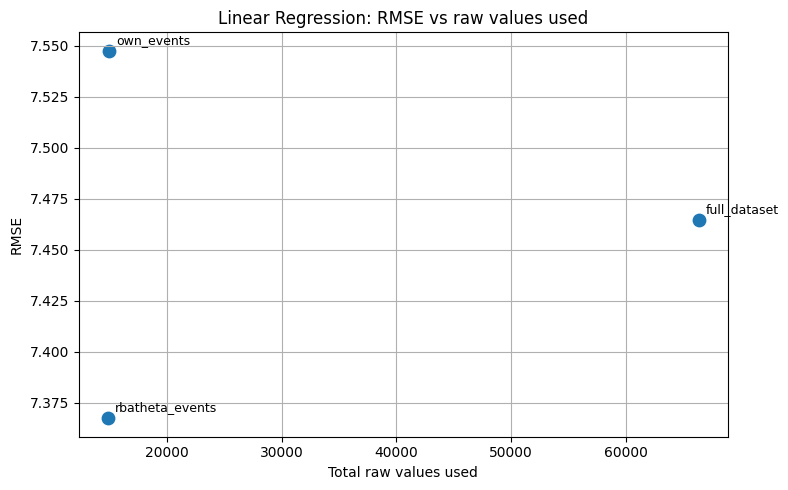

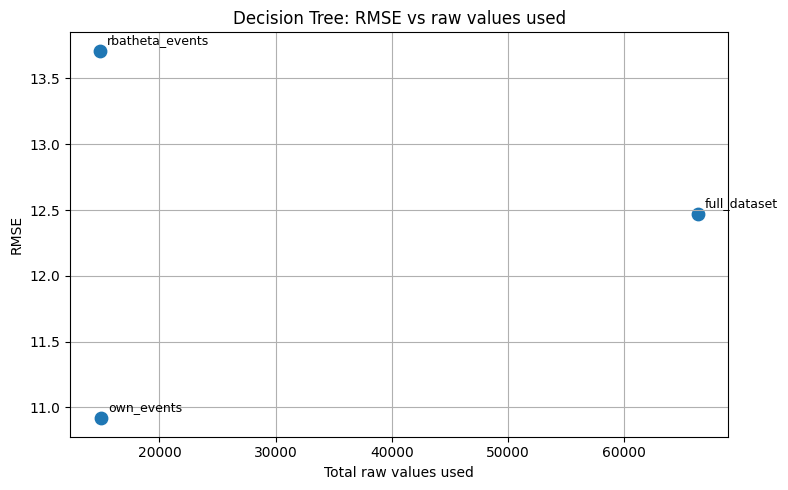

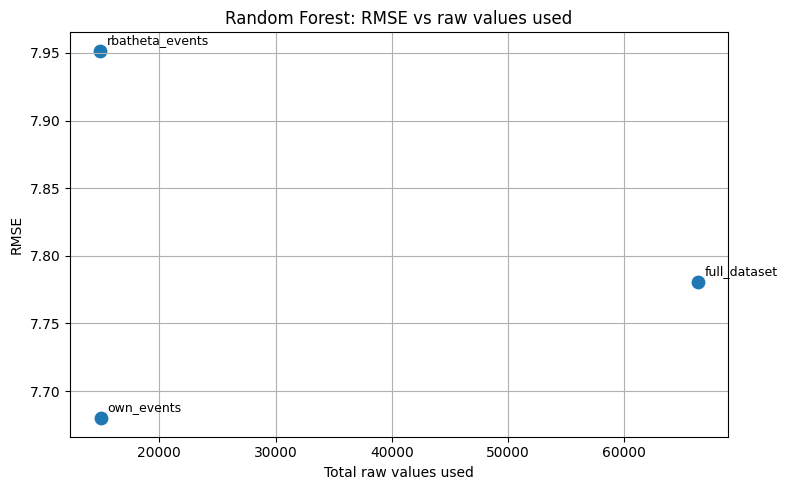

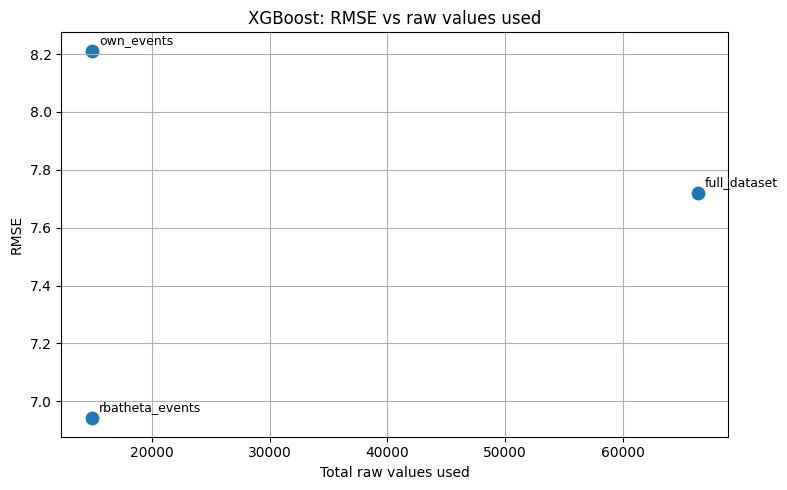

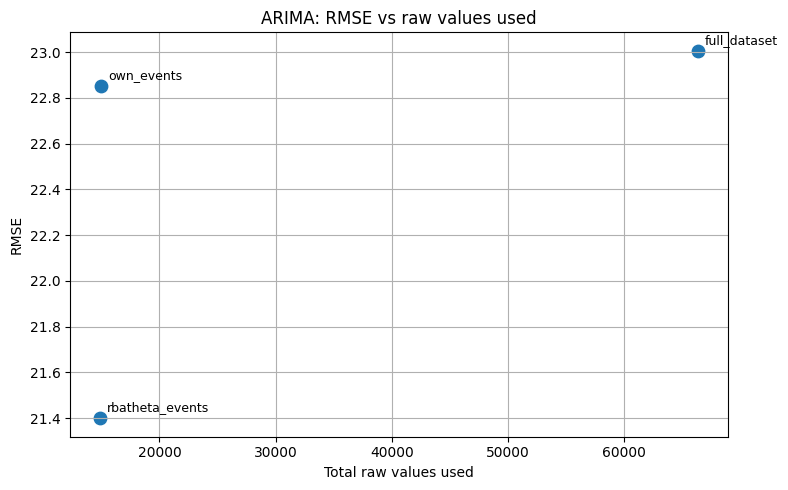

In [49]:
# ============================================================
# TEST PLOT - RMSE VS RAW VALUES USED
# ============================================================

plot_df = test_results_table.copy()

for model_name in plot_df["Model"].unique():

    df_model = plot_df[
        plot_df["Model"] == model_name
    ].copy()

    df_model = df_model.sort_values("total_raw_values")

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_model["total_raw_values"],
        df_model["RMSE"],
        s=80,
    )

    for _, row in df_model.iterrows():
        plt.annotate(
            row["Dataset"],
            (row["total_raw_values"], row["RMSE"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
        )

    plt.xlabel("Total raw values used")
    plt.ylabel("RMSE")
    plt.title(f"{model_name}: RMSE vs raw values used")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [50]:
# ============================================================
# RUN 5 TEST WEEKS FOR ONE ZONE / CALIBRATION
# ============================================================

test_zone_code = "NO2"
test_calibration_config = calibration_configs[2]  # cal_2020_2022

no2_cal2020_2022_week_results, no2_cal2020_2022_data_usage, no2_cal2020_2022_diagnostics = (
    evaluate_zone_calibration_across_test_weeks(
        zone_code=test_zone_code,
        zone_data=all_zone_data[test_zone_code],
        calibration_config=test_calibration_config,
        train_start=train_start,
        train_end=train_end,
        test_weeks=test_weeks,  # all 5 weeks
        rbatheta_base_path=rbatheta_base_path,
        models=models,
        feature_cols_base=feature_cols_base,
        target_col=target_col,
        run_arima=True,  # keep False first to validate quickly
        arima_order=ARIMA_ORDER,
        save_predictions=False,
    )
)

display(no2_cal2020_2022_week_results)

Evaluating zone: NO2
Calibration: cal_2020_2022


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(
C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


Feature columns: ['price_value', 'buy_volume_value', 'sell_volume_value', 'hour_of_day', 'day_of_week', 'month']

--------------------------------------------------------------------------------
Test week: winter_january
Period: 2024-01-15 to 2024-01-21
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.547607
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,10.915831
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,13.711275
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.780343
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.679837
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.951654
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,XGBoost,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.720399



--------------------------------------------------------------------------------
Test week: spring_april
Period: 2024-04-10 to 2024-04-16
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


...


--------------------------------------------------------------------------------
Test week: autumn_september
Period: 2024-09-16 to 2024-09-22
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,8.736257
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,8.818526
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,8.680948
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.158194
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,12.413038
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,11.213396
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Random Forest,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,8.557644
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Random Forest,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,8.509304
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,Random Forest,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,8.310886
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,autumn_september,2024-09-16 to 2024-09-22,XGBoost,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.531050



--------------------------------------------------------------------------------
Test week: winter_december
Period: 2024-12-02 to 2024-12-08
--------------------------------------------------------------------------------
Test shape: (167, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,full_dataset,8764,167,8760,8760,8760,22548,17518,66346,100.000000,0.000000,20.974678
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,own_events,6934,167,1932,4748,2123,4682,1482,14967,22.559009,77.440991,20.969261
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,rbatheta_events,5696,167,2212,1101,2394,9189,0,14896,22.451994,77.548006,21.103930
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,full_dataset,8764,167,8760,8760,8760,22548,17518,66346,100.000000,0.000000,22.812934
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,own_events,6934,167,1932,4748,2123,4682,1482,14967,22.559009,77.440991,22.881088
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,rbatheta_events,5696,167,2212,1101,2394,9189,0,14896,22.451994,77.548006,24.090996
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,full_dataset,8764,167,8760,8760,8760,22548,17518,66346,100.000000,0.000000,20.241245
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,own_events,6934,167,1932,4748,2123,4682,1482,14967,22.559009,77.440991,20.360171
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,rbatheta_events,5696,167,2212,1101,2394,9189,0,14896,22.451994,77.548006,20.397356
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,XGBoost,full_dataset,8764,167,8760,8760,8760,22548,17518,66346,100.000000,0.000000,19.599339


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,7.547607
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,6934,168,1932,4748,2123,4682,1482,14967,22.559009,77.440991,10.915831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,XGBoost,own_events,6934,167,1932,4748,2123,4682,1482,14967,22.559009,77.440991,19.722137
71,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,XGBoost,rbatheta_events,5696,167,2212,1101,2394,9189,0,14896,22.451994,77.548006,19.984155
72,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,ARIMA,full_dataset,8764,167,8760,8760,8760,22548,17518,66346,100.000000,0.000000,42.747308
73,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,ARIMA,own_events,6934,167,1932,4748,2123,4682,1482,14967,22.559009,77.440991,42.663235


In [51]:
# ============================================================
# AVERAGE RESULTS ACROSS 5 TEST WEEKS
# ============================================================

no2_cal2020_2022_average_results = (
    no2_cal2020_2022_week_results
    .groupby(
        [
            "Zone",
            "Calibration",
            "Calibration period",
            "Model",
            "Dataset",
            "Training samples",
            "price_values",
            "buy_volume_values",
            "sell_volume_values",
            "flow_values",
            "capacity_values",
            "total_raw_values",
            "Raw values used (%)",
            "Raw value reduction (%)",
        ],
        as_index=False,
    )
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
    )
)

no2_cal2020_2022_average_results["Raw values used (%)"] = (
    no2_cal2020_2022_average_results["Raw values used (%)"].round(2)
)

no2_cal2020_2022_average_results["Raw value reduction (%)"] = (
    no2_cal2020_2022_average_results["Raw value reduction (%)"].round(2)
)

no2_cal2020_2022_average_results["RMSE_mean"] = (
    no2_cal2020_2022_average_results["RMSE_mean"].round(4)
)

no2_cal2020_2022_average_results["RMSE_std"] = (
    no2_cal2020_2022_average_results["RMSE_std"].round(4)
)


no2_cal2020_2022_average_results = no2_cal2020_2022_average_results.sort_values(
    [
        "Model",
        "total_raw_values",
    ]
).reset_index(drop=True)

display(no2_cal2020_2022_average_results)

,Zone,Calibration,Calibration period,Model,Dataset,Training samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE_mean,RMSE_std
0,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,ARIMA,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,39.7729,10.8972
1,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,ARIMA,own_events,6934,1932,4748,2123,4682,1482,14967,22.56,77.44,39.8064,10.1596
2,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,ARIMA,full_dataset,8764,8760,8760,8760,22548,17518,66346,100.00,0.00,40.1424,10.2675
3,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Decision Tree,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,17.5986,5.3383
4,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Decision Tree,own_events,6934,1932,4748,2123,4682,1482,14967,22.56,77.44,17.2334,5.3416
5,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Decision Tree,full_dataset,8764,8760,8760,8760,22548,17518,66346,100.00,0.00,16.1522,4.3130
6,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Linear Regression,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,12.1485,5.3933
7,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Linear Regression,own_events,6934,1932,4748,2123,4682,1482,14967,22.56,77.44,12.2497,5.2666
8,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Linear Regression,full_dataset,8764,8760,8760,8760,22548,17518,66346,100.00,0.00,12.1759,5.3045
9,NO2,cal_2020_2022,2020-01-01 to 2022-12-31,Random Forest,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,12.2449,5.0093


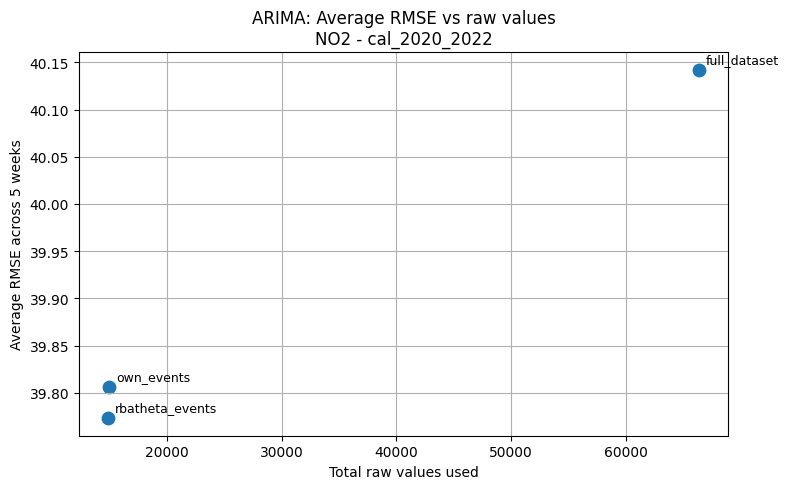

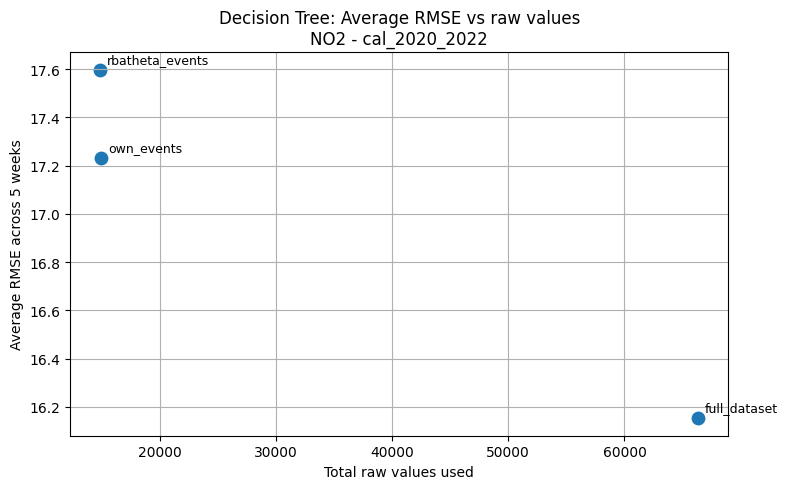

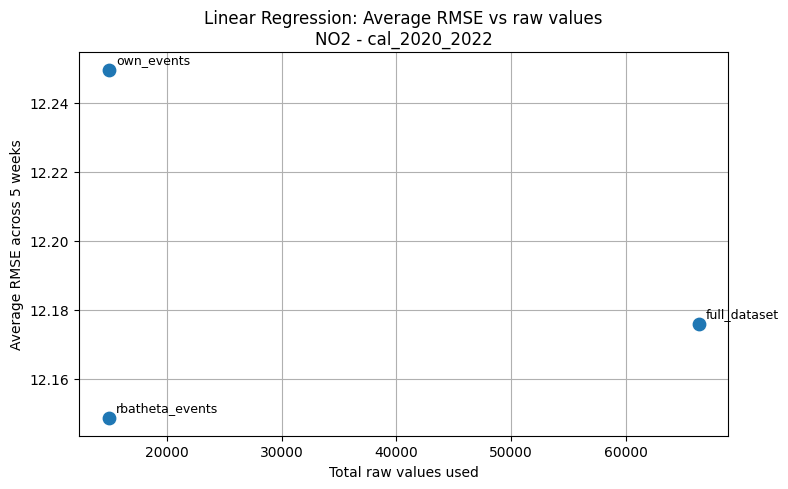

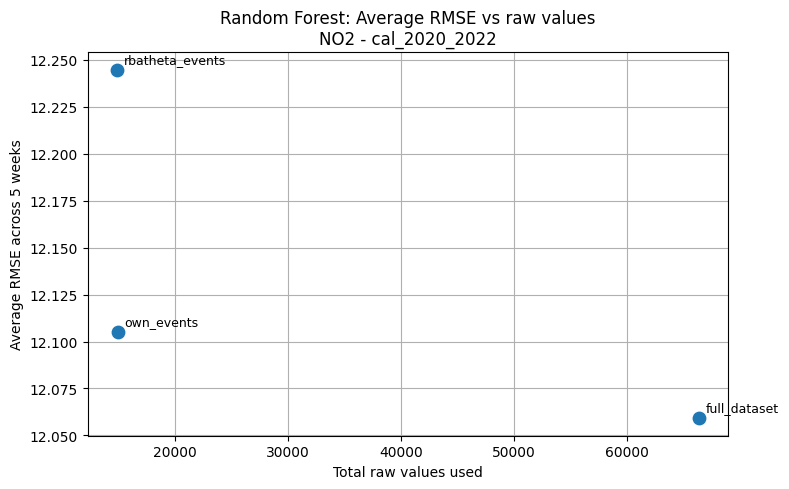

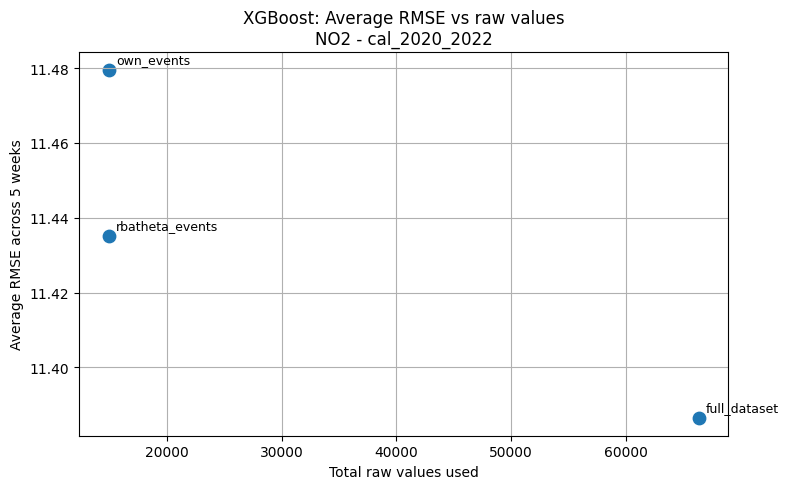

In [52]:
# ============================================================
# PLOT - AVERAGE RMSE VS RAW VALUES
# ============================================================

plot_df = no2_cal2020_2022_average_results.copy()

for model_name in plot_df["Model"].unique():

    df_model = plot_df[
        plot_df["Model"] == model_name
    ].copy()

    df_model = df_model.sort_values("total_raw_values")

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_model["total_raw_values"],
        df_model["RMSE_mean"],
        s=80,
    )

    for _, row in df_model.iterrows():
        plt.annotate(
            row["Dataset"],
            (row["total_raw_values"], row["RMSE_mean"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
        )

    plt.xlabel("Total raw values used")
    plt.ylabel("Average RMSE across 5 weeks")
    plt.title(f"{model_name}: Average RMSE vs raw values\nNO2 - cal_2020_2022")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [54]:
# ============================================================
# RUN FINAL EXPERIMENT
# 2 zones × 3 calibrations × 5 test weeks
# ============================================================

RUN_ARIMA_FINAL = True
SAVE_PREDICTIONS = True

final_results_dir = results_base_dir / "final_run_arima"
tables_dir = final_results_dir / "tables"
predictions_dir = final_results_dir / "predictions"

tables_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

all_experiment_results = []
all_experiment_data_usage = []

for zone_code in selected_zones:

    print("\n" + "#" * 100)
    print("STARTING ZONE:", zone_code)
    print("#" * 100)

    for calibration_config in calibration_configs:

        calibration_name = calibration_config["calibration_name"]

        print("\n" + "=" * 100)
        print("ZONE:", zone_code)
        print("CALIBRATION:", calibration_name)
        print("=" * 100)

        zone_calibration_predictions_dir = (
            predictions_dir
            / zone_code
            / calibration_name
        )

        results_table, data_usage_table, diagnostics = (
            evaluate_zone_calibration_across_test_weeks(
                zone_code=zone_code,
                zone_data=all_zone_data[zone_code],
                calibration_config=calibration_config,
                train_start=train_start,
                train_end=train_end,
                test_weeks=test_weeks,
                rbatheta_base_path=rbatheta_base_path,
                models=models,
                feature_cols_base=feature_cols_base,
                target_col=target_col,
                run_arima=RUN_ARIMA_FINAL,
                arima_order=ARIMA_ORDER,
                save_predictions=SAVE_PREDICTIONS,
                predictions_dir=zone_calibration_predictions_dir,
            )
        )

        all_experiment_results.append(results_table)
        all_experiment_data_usage.append(data_usage_table)

        safe_name = f"{zone_code}_{calibration_name}"

        results_table.to_csv(
            tables_dir / f"{safe_name}_week_results.csv",
            index=False,
        )

        results_table.to_excel(
            tables_dir / f"{safe_name}_week_results.xlsx",
            index=False,
        )

        data_usage_table.to_csv(
            tables_dir / f"{safe_name}_data_usage.csv",
            index=False,
        )

        data_usage_table.to_excel(
            tables_dir / f"{safe_name}_data_usage.xlsx",
            index=False,
        )

        print("Saved:", safe_name)

all_week_results_table = pd.concat(
    all_experiment_results,
    ignore_index=True,
)

all_data_usage_final = pd.concat(
    all_experiment_data_usage,
    ignore_index=True,
)

all_week_results_table.to_csv(
    tables_dir / "all_week_results.csv",
    index=False,
)

all_week_results_table.to_excel(
    tables_dir / "all_week_results.xlsx",
    index=False,
)

all_data_usage_final.to_csv(
    tables_dir / "all_data_usage.csv",
    index=False,
)

all_data_usage_final.to_excel(
    tables_dir / "all_data_usage.xlsx",
    index=False,
)

print("\n" + "#" * 100)
print("FINAL EXPERIMENT COMPLETED")
print("#" * 100)
print("Results saved in:")
print(tables_dir)

print("\nAll week results shape:", all_week_results_table.shape)
print("All data usage shape:", all_data_usage_final.shape)

display(all_week_results_table.head())
display(all_data_usage_final.head())


####################################################################################################
STARTING ZONE: NO2
####################################################################################################

ZONE: NO2
CALIBRATION: cal_2020
Evaluating zone: NO2
Calibration: cal_2020


C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\3573909186.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(
C:\Users\HUGO\AppData\Local\Temp\ipykernel_23972\151460872.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


Feature columns: ['price_value', 'buy_volume_value', 'sell_volume_value', 'hour_of_day', 'day_of_week', 'month']

--------------------------------------------------------------------------------
Test week: winter_january
Period: 2024-01-15 to 2024-01-21
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,8764,168,8761,6266,3233,8403,1310,27973,42.162301,57.837699,7.464502
2,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,8764,168,8761,6266,3233,8403,1310,27973,42.162301,57.837699,12.471897
5,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,13.711275
6,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.780343
7,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,own_events,8764,168,8761,6266,3233,8403,1310,27973,42.162301,57.837699,7.780343
8,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Random Forest,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.951654
9,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,XGBoost,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.720399



--------------------------------------------------------------------------------
Test week: spring_april
Period: 2024-04-10 to 2024-04-16
--------------------------------------------------------------------------------
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


...


--------------------------------------------------------------------------------
Test week: winter_december
Period: 2024-12-02 to 2024-12-08
--------------------------------------------------------------------------------
Test shape: (167, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,full_dataset,8764,167,8760,8760,8760,22961,70072,119313,100.000000,0.000000,1.511094
1,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,own_events,8375,167,3944,5078,3566,2325,17051,31964,26.790040,73.209960,1.542767
2,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Linear Regression,rbatheta_events,3556,167,1306,1831,1940,5914,0,10991,9.211905,90.788095,2.201012
3,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,full_dataset,8764,167,8760,8760,8760,22961,70072,119313,100.000000,0.000000,2.029054
4,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,own_events,8375,167,3944,5078,3566,2325,17051,31964,26.790040,73.209960,1.902049
5,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Decision Tree,rbatheta_events,3556,167,1306,1831,1940,5914,0,10991,9.211905,90.788095,2.573114
6,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,full_dataset,8764,167,8760,8760,8760,22961,70072,119313,100.000000,0.000000,1.221669
7,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,own_events,8375,167,3944,5078,3566,2325,17051,31964,26.790040,73.209960,1.198944
8,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,Random Forest,rbatheta_events,3556,167,1306,1831,1940,5914,0,10991,9.211905,90.788095,1.162385
9,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,winter_december,2024-12-02 to 2024-12-08,XGBoost,full_dataset,8764,167,8760,8760,8760,22961,70072,119313,100.000000,0.000000,4.280278


Saved: NO4_cal_2020_2022

####################################################################################################
FINAL EXPERIMENT COMPLETED
####################################################################################################
Results saved in:
C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\final_event_training_experiment\final_run_arima\tables

All week results shape: (450, 18)
All data usage shape: (18, 12)


,Zone,Calibration,Calibration period,Test week,Test period,Model,Dataset,Training samples,Test samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE
0,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,7.464502
1,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,8764,168,8761,6266,3233,8403,1310,27973,42.162301,57.837699,7.464502
2,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,5696,168,2212,1101,2394,9189,0,14896,22.451994,77.548006,7.367459
3,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,8764,168,8760,8760,8760,22548,17518,66346,100.000000,0.000000,12.471897
4,NO2,cal_2020,2020-01-01 to 2020-12-31,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,8764,168,8761,6266,3233,8403,1310,27973,42.162301,57.837699,12.471897


,Zone,Calibration,Calibration period,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,NO2,cal_2020,2020-01-01 to 2020-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
1,NO2,cal_2020,2020-01-01 to 2020-12-31,own_events,8761,6266,3233,8403,1310,27973,42.162301,57.837699
2,NO2,cal_2020,2020-01-01 to 2020-12-31,rbatheta_events,2212,1101,2394,9189,0,14896,22.451994,77.548006
3,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,full_dataset,8760,8760,8760,22548,17518,66346,100.000000,0.000000
4,NO2,cal_2020_2021,2020-01-01 to 2021-12-31,own_events,6447,5600,2832,7074,1482,23435,35.322401,64.677599


In [55]:
# ============================================================
# AVERAGE PERFORMANCE ACROSS 5 TEST WEEKS
# ============================================================

average_results_table = (
    all_week_results_table
    .groupby(
        [
            "Zone",
            "Calibration",
            "Calibration period",
            "Model",
            "Dataset",
            "Training samples",
            "price_values",
            "buy_volume_values",
            "sell_volume_values",
            "flow_values",
            "capacity_values",
            "total_raw_values",
            "Raw values used (%)",
            "Raw value reduction (%)",
        ],
        as_index=False,
    )
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
    )
)

average_results_table = average_results_table.sort_values(
    [
        "Zone",
        "Calibration",
        "Model",
        "total_raw_values",
    ]
).reset_index(drop=True)

average_results_table["Raw values used (%)"] = (
    average_results_table["Raw values used (%)"].round(2)
)

average_results_table["Raw value reduction (%)"] = (
    average_results_table["Raw value reduction (%)"].round(2)
)

average_results_table["RMSE_mean"] = average_results_table["RMSE_mean"].round(4)
average_results_table["RMSE_std"] = average_results_table["RMSE_std"].round(4)

average_results_table.to_csv(
    tables_dir / "average_results_5weeks.csv",
    index=False,
)

average_results_table.to_excel(
    tables_dir / "average_results_5weeks.xlsx",
    index=False,
)

display(average_results_table)

,Zone,Calibration,Calibration period,Model,Dataset,Training samples,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE_mean,RMSE_std
0,NO2,cal_2020,2020-01-01 to 2020-12-31,ARIMA,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,39.7729,10.8972
1,NO2,cal_2020,2020-01-01 to 2020-12-31,ARIMA,own_events,8764,8761,6266,3233,8403,1310,27973,42.16,57.84,40.1424,10.2675
2,NO2,cal_2020,2020-01-01 to 2020-12-31,ARIMA,full_dataset,8764,8760,8760,8760,22548,17518,66346,100.00,0.00,40.1424,10.2675
3,NO2,cal_2020,2020-01-01 to 2020-12-31,Decision Tree,rbatheta_events,5696,2212,1101,2394,9189,0,14896,22.45,77.55,17.5986,5.3383
4,NO2,cal_2020,2020-01-01 to 2020-12-31,Decision Tree,own_events,8764,8761,6266,3233,8403,1310,27973,42.16,57.84,16.1522,4.3130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,Random Forest,own_events,8375,3944,5078,3566,2325,17051,31964,26.79,73.21,3.9887,3.9389
86,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,Random Forest,full_dataset,8764,8760,8760,8760,22961,70072,119313,100.00,0.00,3.8422,3.5496
87,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,XGBoost,rbatheta_events,3556,1306,1831,1940,5914,0,10991,9.21,90.79,8.0552,8.9771
88,NO4,cal_2020_2022,2020-01-01 to 2022-12-31,XGBoost,own_events,8375,3944,5078,3566,2325,17051,31964,26.79,73.21,3.5241,1.6423


In [56]:
# ============================================================
# COMPACT FINAL TABLE
# ============================================================

presentation_results_table = average_results_table[
    [
        "Zone",
        "Calibration",
        "Model",
        "Dataset",
        "Training samples",
        "total_raw_values",
        "Raw values used (%)",
        "Raw value reduction (%)",
        "RMSE_mean",
    ]
].copy()

presentation_results_table = presentation_results_table.sort_values(
    [
        "Zone",
        "Model",
        "Calibration",
        "total_raw_values",
    ]
).reset_index(drop=True)

presentation_results_table.to_csv(
    tables_dir / "presentation_results_table.csv",
    index=False,
)

presentation_results_table.to_excel(
    tables_dir / "presentation_results_table.xlsx",
    index=False,
)

display(presentation_results_table)

,Zone,Calibration,Model,Dataset,Training samples,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE_mean
0,NO2,cal_2020,ARIMA,rbatheta_events,5696,14896,22.45,77.55,39.7729
1,NO2,cal_2020,ARIMA,own_events,8764,27973,42.16,57.84,40.1424
2,NO2,cal_2020,ARIMA,full_dataset,8764,66346,100.00,0.00,40.1424
3,NO2,cal_2020_2021,ARIMA,rbatheta_events,5696,14896,22.45,77.55,39.7729
4,NO2,cal_2020_2021,ARIMA,own_events,8532,23435,35.32,64.68,40.1587
...,...,...,...,...,...,...,...,...,...
85,NO4,cal_2020_2021,XGBoost,own_events,8469,32829,27.52,72.48,3.6753
86,NO4,cal_2020_2021,XGBoost,full_dataset,8764,119313,100.00,0.00,3.7107
87,NO4,cal_2020_2022,XGBoost,rbatheta_events,3556,10991,9.21,90.79,8.0552
88,NO4,cal_2020_2022,XGBoost,own_events,8375,31964,26.79,73.21,3.5241


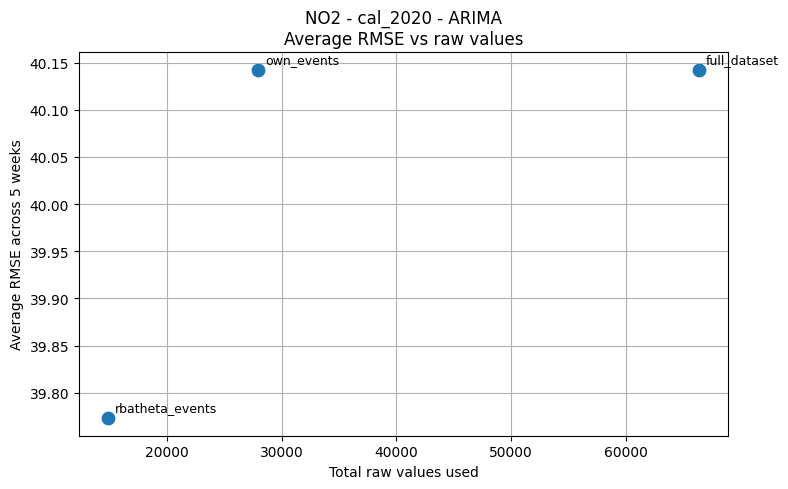

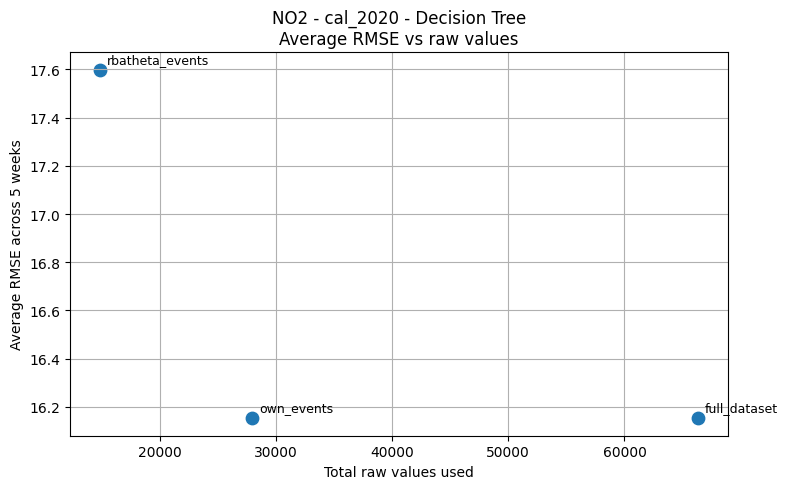

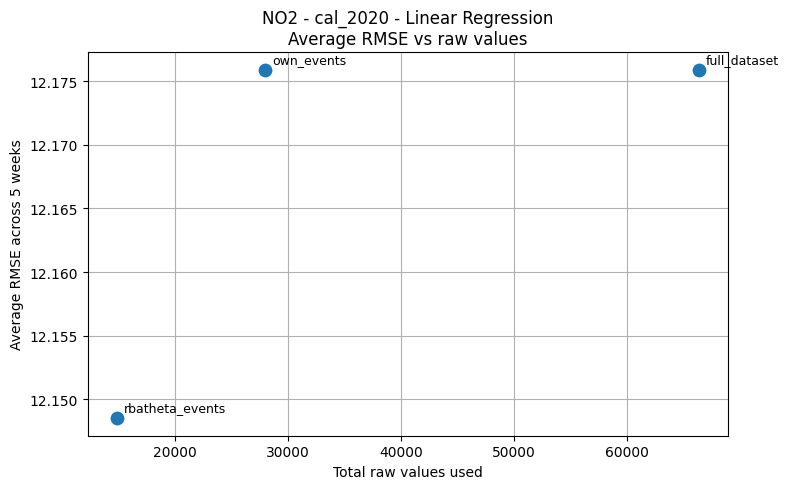

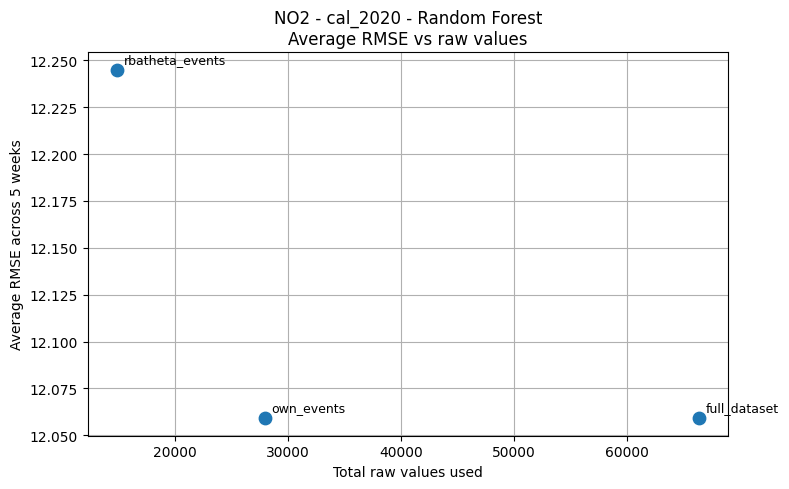

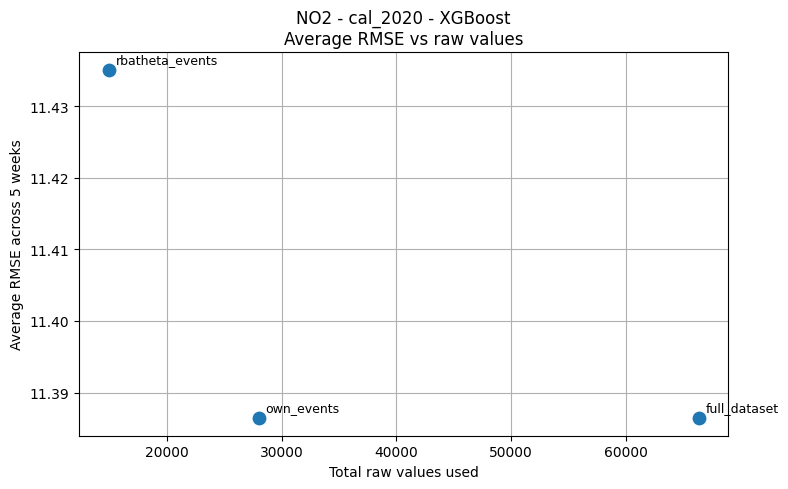

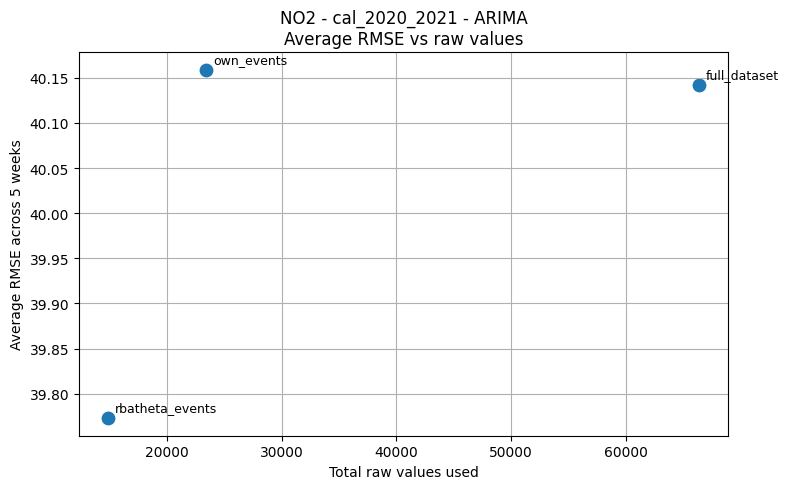

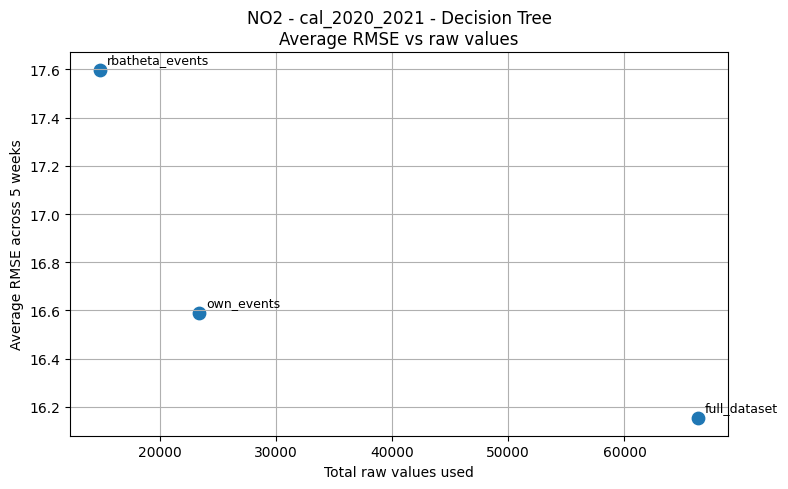

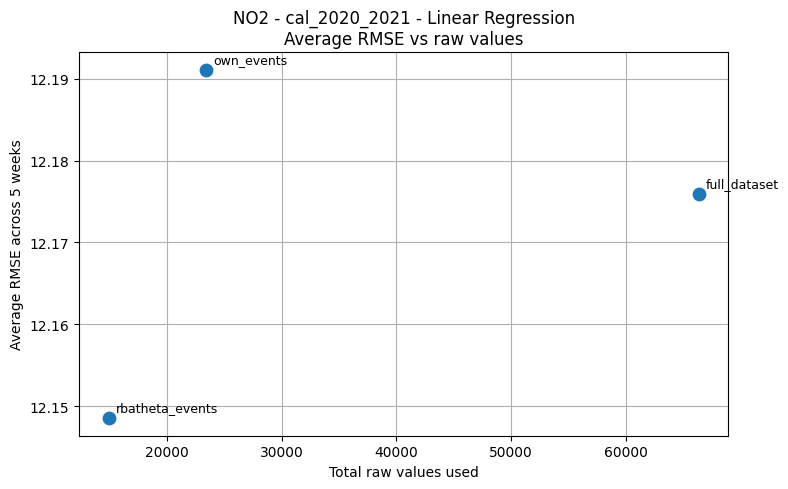

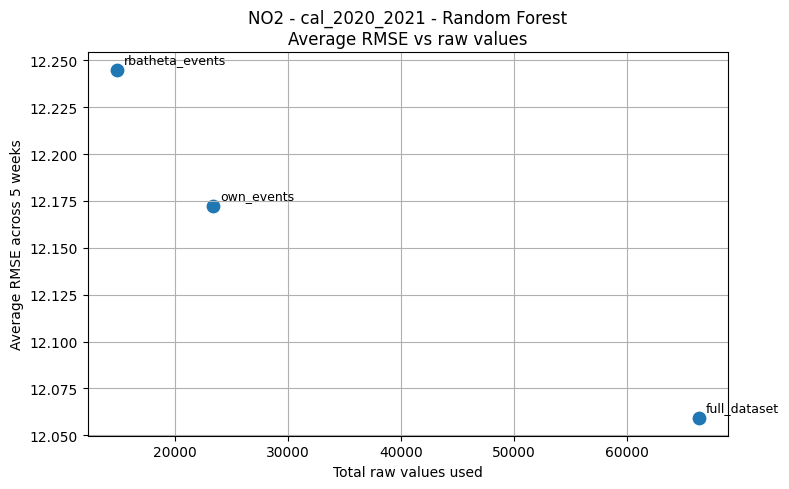

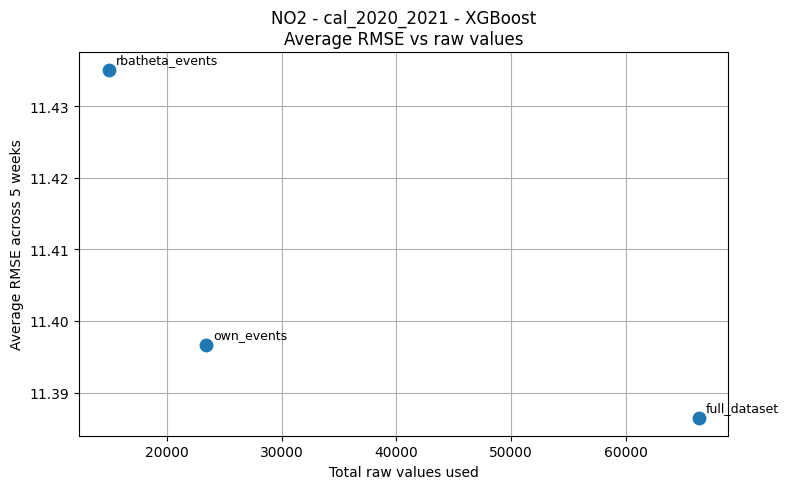

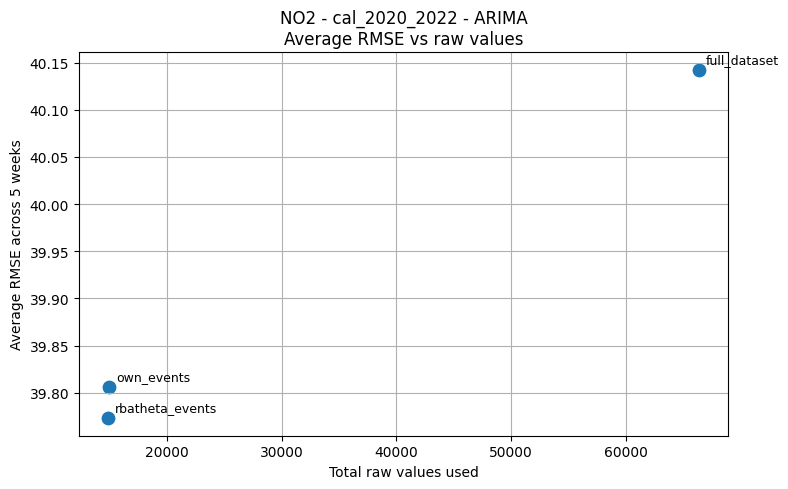

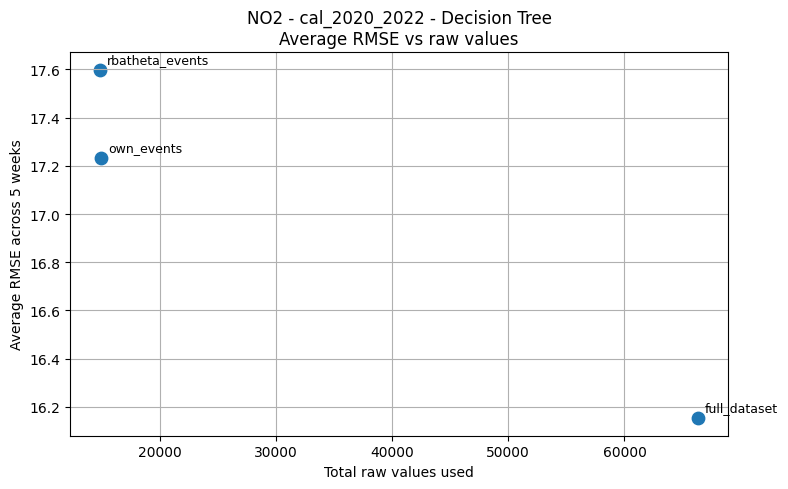

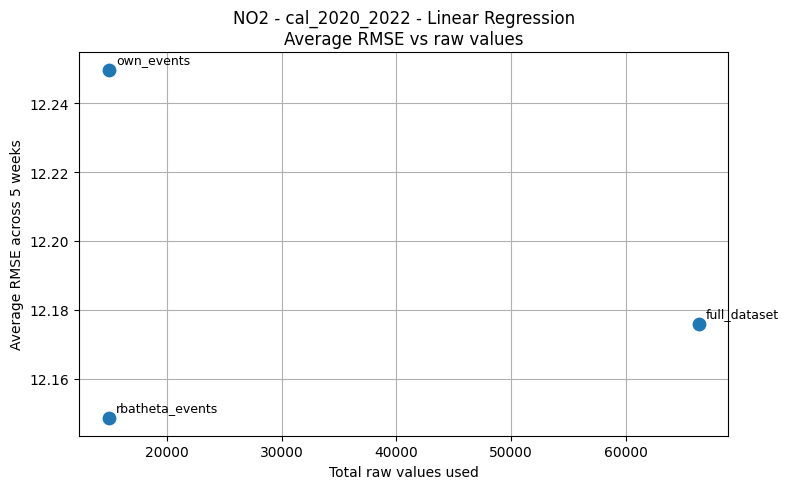

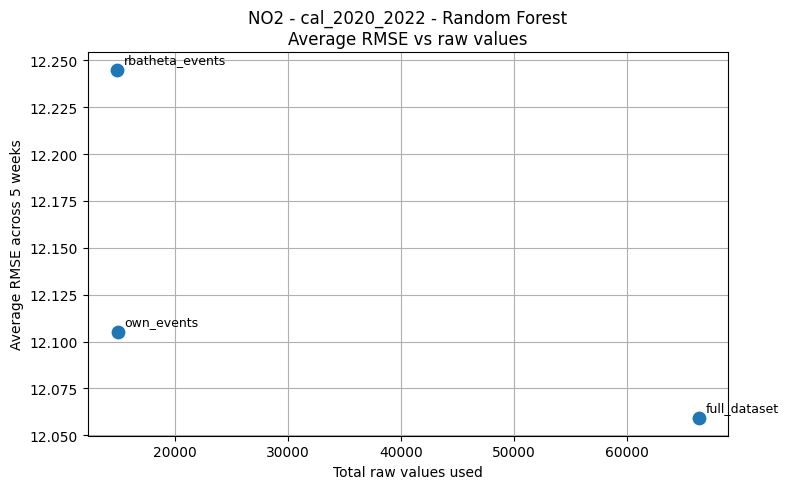

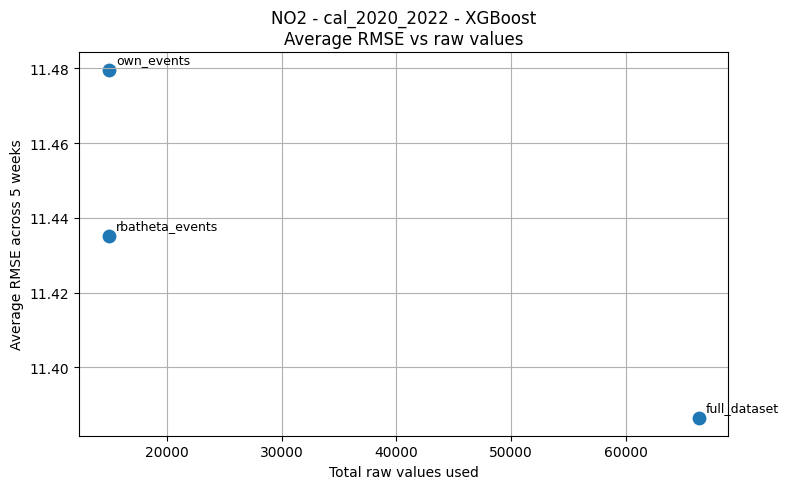

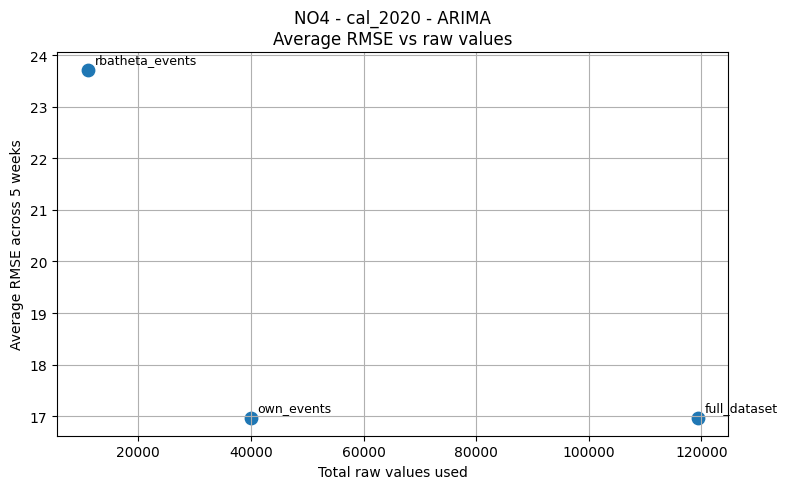

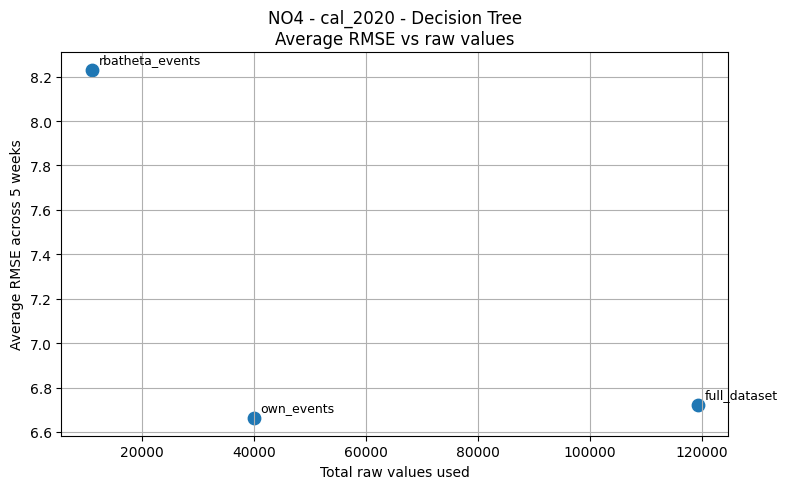

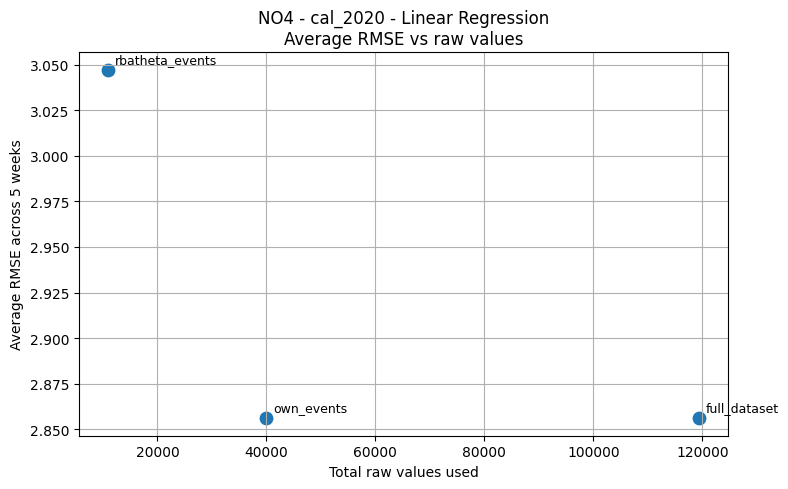

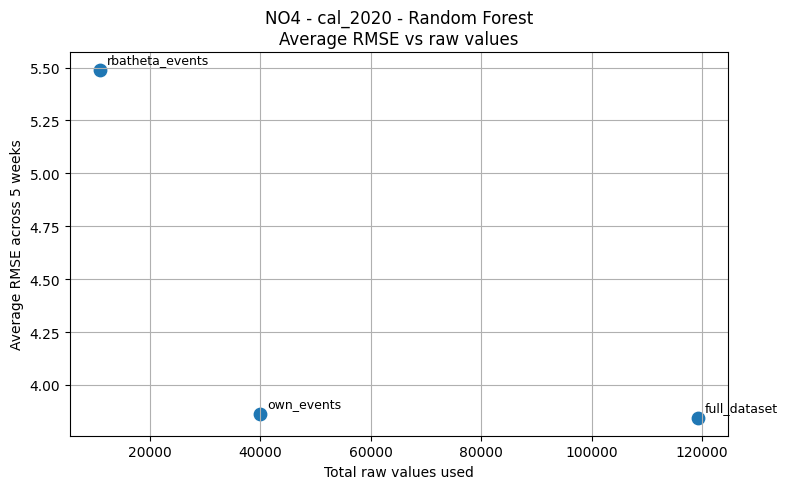

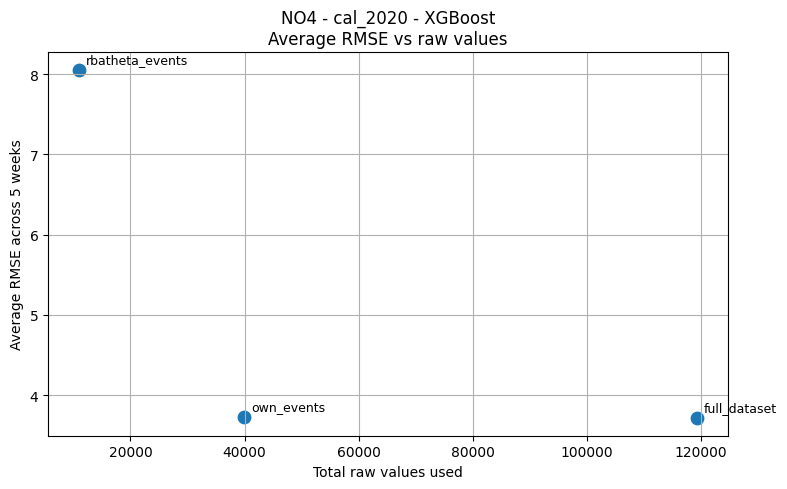

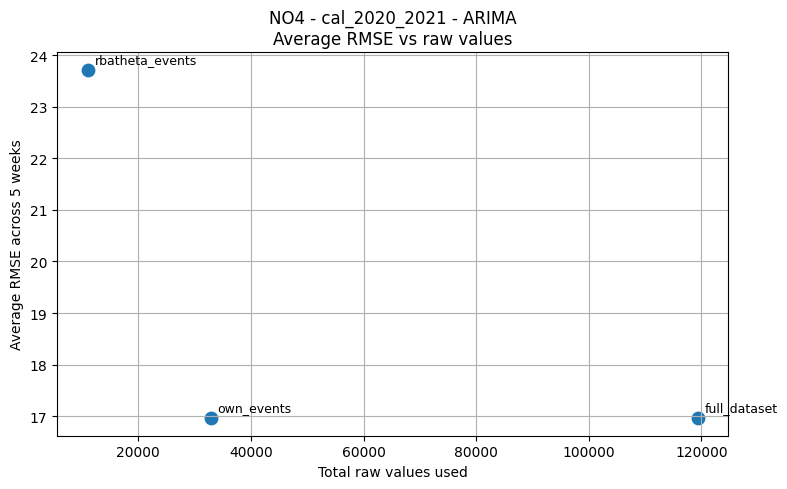

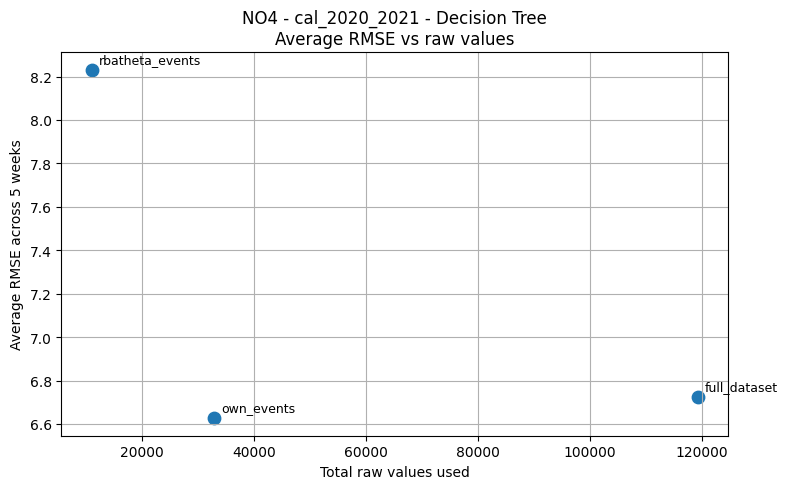

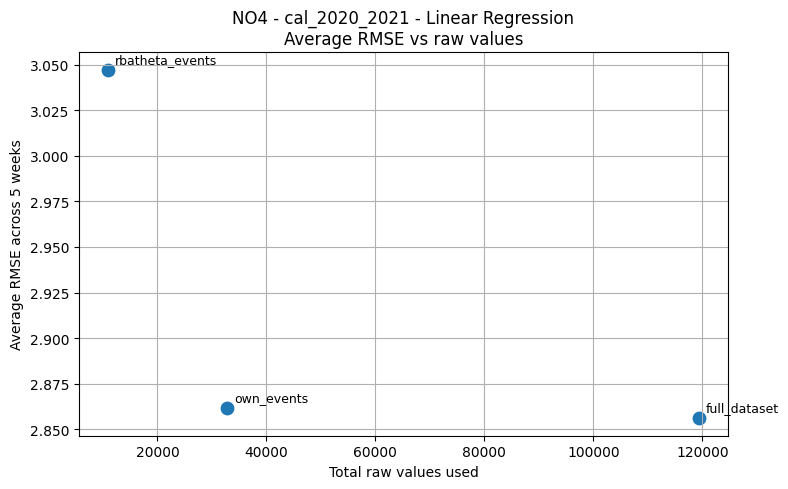

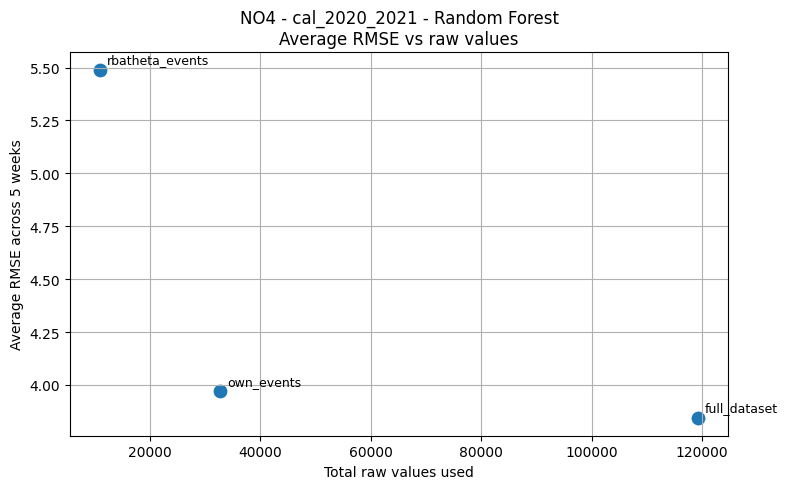

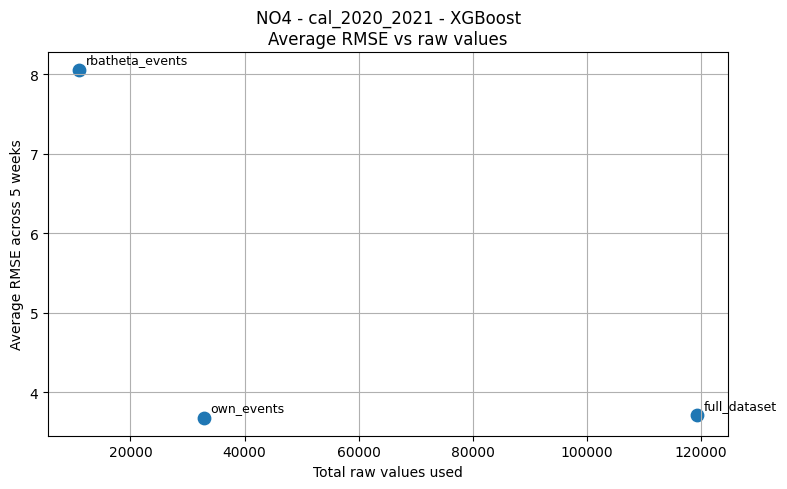

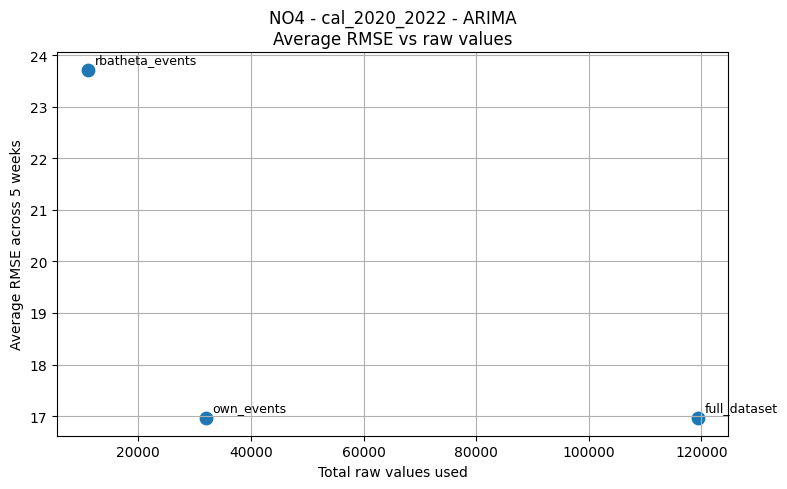

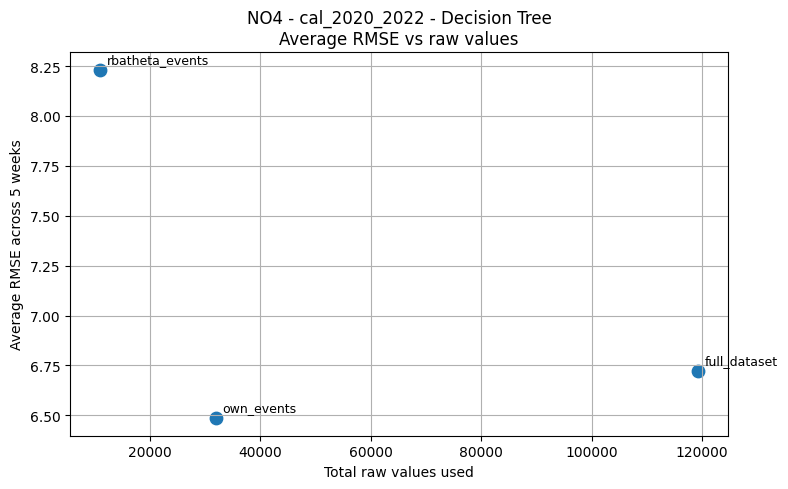

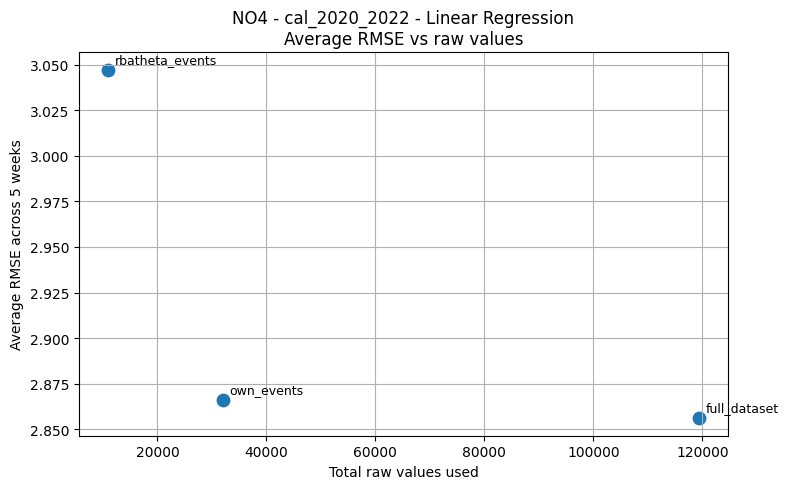

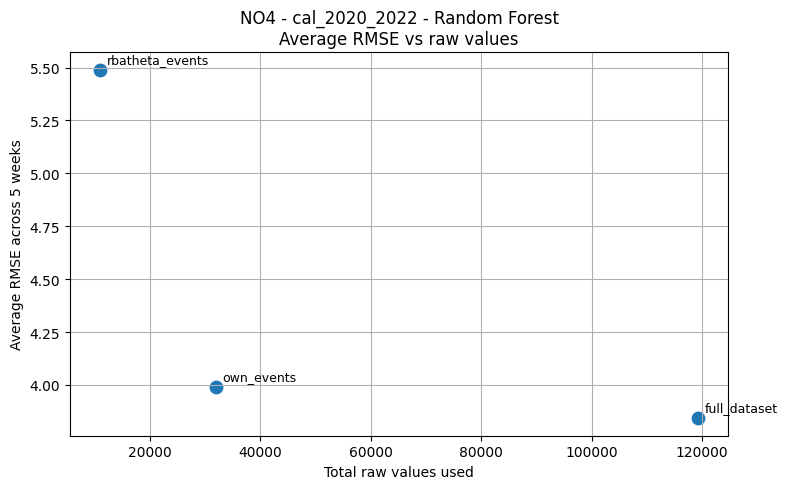

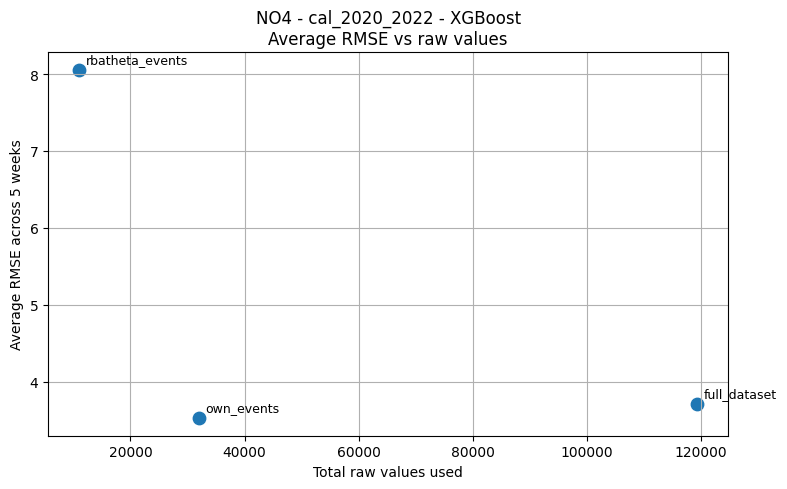

RMSE plots saved in:
C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\final_event_training_experiment\final_run_arima\plots


In [57]:
# ============================================================
# FINAL PLOTS - RMSE VS RAW VALUES
# ============================================================

plots_dir = final_results_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

for zone_code in average_results_table["Zone"].unique():

    for calibration_name in average_results_table["Calibration"].unique():

        df_plot_base = average_results_table[
            (average_results_table["Zone"] == zone_code)
            & (average_results_table["Calibration"] == calibration_name)
        ].copy()

        if df_plot_base.empty:
            continue

        for model_name in df_plot_base["Model"].unique():

            df_plot = df_plot_base[
                df_plot_base["Model"] == model_name
            ].copy()

            df_plot = df_plot.sort_values("total_raw_values")

            plt.figure(figsize=(8, 5))

            plt.scatter(
                df_plot["total_raw_values"],
                df_plot["RMSE_mean"],
                s=80,
            )

            for _, row in df_plot.iterrows():
                plt.annotate(
                    row["Dataset"],
                    (row["total_raw_values"], row["RMSE_mean"]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=9,
                )

            plt.xlabel("Total raw values used")
            plt.ylabel("Average RMSE across 5 weeks")
            plt.title(
                f"{zone_code} - {calibration_name} - {model_name}\n"
                "Average RMSE vs raw values"
            )
            plt.grid(True)
            plt.tight_layout()

            safe_model = model_name.replace(" ", "_").replace("/", "_")
            plot_path = (
                plots_dir
                / f"{zone_code}_{calibration_name}_{safe_model}_RMSE_vs_raw_values.png"
            )

            plt.savefig(plot_path, dpi=300, bbox_inches="tight")
            plt.show()

print("RMSE plots saved in:")
print(plots_dir)

In [58]:
# ============================================================
# AVERAGE ACROSS MODELS BY ZONE, CALIBRATION AND DATASET
# ============================================================

avg_by_calibration_table = (
    presentation_results_table
    .groupby(
        [
            "Zone",
            "Calibration",
            "Dataset",
        ],
        as_index=False
    )
    .agg(
        Training_samples_mean=("Training samples", "mean"),
        total_raw_values=("total_raw_values", "mean"),
        Raw_values_used_pct=("Raw values used (%)", "mean"),
        Raw_value_reduction_pct=("Raw value reduction (%)", "mean"),
        RMSE_mean=("RMSE_mean", "mean"),
        n_models=("Model", "nunique"),
    )
)

# Round values for presentation
avg_by_calibration_table["Training_samples_mean"] = (
    avg_by_calibration_table["Training_samples_mean"].round(0).astype(int)
)

avg_by_calibration_table["total_raw_values"] = (
    avg_by_calibration_table["total_raw_values"].round(0).astype(int)
)

avg_by_calibration_table["Raw_values_used_pct"] = (
    avg_by_calibration_table["Raw_values_used_pct"].round(2)
)

avg_by_calibration_table["Raw_value_reduction_pct"] = (
    avg_by_calibration_table["Raw_value_reduction_pct"].round(2)
)

avg_by_calibration_table["RMSE_mean"] = (
    avg_by_calibration_table["RMSE_mean"].round(4)
)

# Sort for readability
avg_by_calibration_table = avg_by_calibration_table.sort_values(
    [
        "Zone",
        "Calibration",
        "total_raw_values",
    ]
).reset_index(drop=True)

# Save outputs
avg_by_calibration_table.to_csv(
    tables_dir / "avg_by_calibration_table.csv",
    index=False,
)

avg_by_calibration_table.to_excel(
    tables_dir / "avg_by_calibration_table.xlsx",
    index=False,
)

display(avg_by_calibration_table)

,Zone,Calibration,Dataset,Training_samples_mean,total_raw_values,Raw_values_used_pct,Raw_value_reduction_pct,RMSE_mean,n_models
0,NO2,cal_2020,rbatheta_events,5696,14896,22.45,77.55,18.6400,5
1,NO2,cal_2020,own_events,8764,27973,42.16,57.84,18.3832,5
2,NO2,cal_2020,full_dataset,8764,66346,100.00,0.00,18.3832,5
3,NO2,cal_2020_2021,rbatheta_events,5696,14896,22.45,77.55,18.6400,5
4,NO2,cal_2020_2021,own_events,8532,23435,35.32,64.68,18.5017,5
5,NO2,cal_2020_2021,full_dataset,8764,66346,100.00,0.00,18.3832,5
6,NO2,cal_2020_2022,rbatheta_events,5696,14896,22.45,77.55,18.6400,5
7,NO2,cal_2020_2022,own_events,6934,14967,22.56,77.44,18.5749,5
8,NO2,cal_2020_2022,full_dataset,8764,66346,100.00,0.00,18.3832,5
9,NO4,cal_2020,rbatheta_events,3556,10991,9.21,90.79,9.7073,5


In [90]:
# ============================================================
# AVERAGE TABLE WITHOUT REPEATED ROWS
# full_dataset and rbatheta_events appear once per zone
# own_events appears once per zone and calibration
# ============================================================

# -----------------------------
# 1. Average full_dataset and rbatheta_events
#    They do not depend on calibration
# -----------------------------

fixed_datasets_table = (
    presentation_results_table[
        presentation_results_table["Dataset"].isin(
            ["full_dataset", "rbatheta_events"]
        )
    ]
    .groupby(
        [
            "Zone",
            "Dataset",
        ],
        as_index=False
    )
    .agg(
        Training_samples_mean=("Training samples", "mean"),
        total_raw_values=("total_raw_values", "mean"),
        Raw_values_used_pct=("Raw values used (%)", "mean"),
        Raw_value_reduction_pct=("Raw value reduction (%)", "mean"),
        RMSE_mean=("RMSE_mean", "mean"),
        n_models=("Model", "nunique"),
    )
)

fixed_datasets_table["Calibration"] = "-"

# -----------------------------
# 2. Average own_events by calibration
#    This dataset does depend on calibration
# -----------------------------

own_events_table = (
    presentation_results_table[
        presentation_results_table["Dataset"] == "own_events"
    ]
    .groupby(
        [
            "Zone",
            "Calibration",
            "Dataset",
        ],
        as_index=False
    )
    .agg(
        Training_samples_mean=("Training samples", "mean"),
        total_raw_values=("total_raw_values", "mean"),
        Raw_values_used_pct=("Raw values used (%)", "mean"),
        Raw_value_reduction_pct=("Raw value reduction (%)", "mean"),
        RMSE_mean=("RMSE_mean", "mean"),
        n_models=("Model", "nunique"),
    )
)

# -----------------------------
# 3. Combine both tables
# -----------------------------

avg_by_calibration_table_clean = pd.concat(
    [
        fixed_datasets_table,
        own_events_table,
    ],
    ignore_index=True
)

# Reorder columns
avg_by_calibration_table_clean = avg_by_calibration_table_clean[
    [
        "Zone",
        "Calibration",
        "Dataset",
        "Training_samples_mean",
        "total_raw_values",
        "Raw_values_used_pct",
        "Raw_value_reduction_pct",
        "RMSE_mean",
        "n_models",
    ]
]

# -----------------------------
# 4. Round values
# -----------------------------

avg_by_calibration_table_clean["Training_samples_mean"] = (
    avg_by_calibration_table_clean["Training_samples_mean"].round(0).astype(int)
)

avg_by_calibration_table_clean["total_raw_values"] = (
    avg_by_calibration_table_clean["total_raw_values"].round(0).astype(int)
)

avg_by_calibration_table_clean["Raw_values_used_pct"] = (
    avg_by_calibration_table_clean["Raw_values_used_pct"].round(2)
)

avg_by_calibration_table_clean["Raw_value_reduction_pct"] = (
    avg_by_calibration_table_clean["Raw_value_reduction_pct"].round(2)
)

avg_by_calibration_table_clean["RMSE_mean"] = (
    avg_by_calibration_table_clean["RMSE_mean"].round(4)
)

# -----------------------------
# 5. Sort for readability
# -----------------------------

dataset_order = {
    "full_dataset": 0,
    "rbatheta_events": 1,
    "own_events": 2,
}

avg_by_calibration_table_clean["dataset_order"] = (
    avg_by_calibration_table_clean["Dataset"].map(dataset_order)
)

avg_by_calibration_table_clean = (
    avg_by_calibration_table_clean
    .sort_values(
        [
            "Zone",
            "dataset_order",
            "Calibration",
        ]
    )
    .drop(columns=["dataset_order"])
    .reset_index(drop=True)
)

display(avg_by_calibration_table_clean)

,Zone,Calibration,Dataset,Training_samples_mean,total_raw_values,Raw_values_used_pct,Raw_value_reduction_pct,RMSE_mean,n_models
0,NO2,-,full_dataset,8764,66346,100.00,0.00,18.3832,5
1,NO2,-,rbatheta_events,5696,14896,22.45,77.55,18.6400,5
2,NO2,cal_2020,own_events,8764,27973,42.16,57.84,18.3832,5
3,NO2,cal_2020_2021,own_events,8532,23435,35.32,64.68,18.5017,5
4,NO2,cal_2020_2022,own_events,6934,14967,22.56,77.44,18.5749,5
5,NO4,-,full_dataset,8764,119313,100.00,0.00,6.8185,5
6,NO4,-,rbatheta_events,3556,10991,9.21,90.79,9.7073,5
7,NO4,cal_2020,own_events,8758,39953,33.49,66.51,6.8137,5
8,NO4,cal_2020_2021,own_events,8469,32829,27.52,72.48,6.8209,5
9,NO4,cal_2020_2022,own_events,8375,31964,26.79,73.21,6.7645,5


Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\final_event_training_experiment\final_run_arima\summary_plots_average_models\NO2_Average_RMSE_vs_raw_values.png


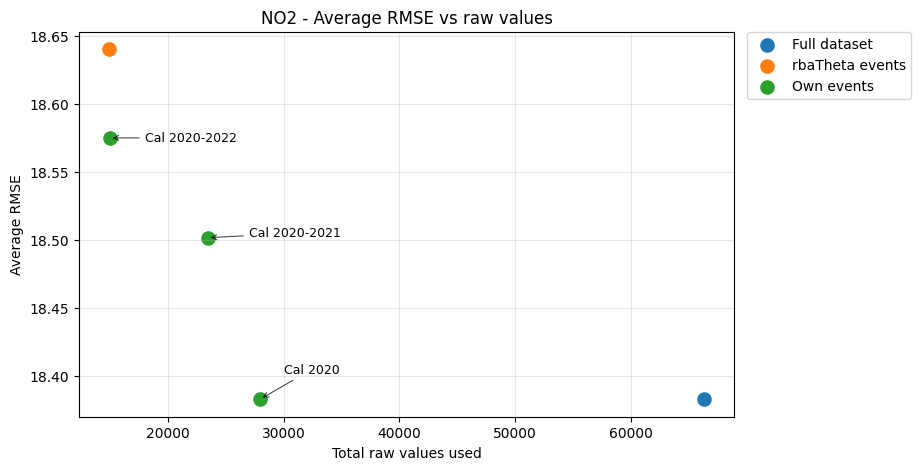

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\final_event_training_experiment\final_run_arima\summary_plots_average_models\NO4_Average_RMSE_vs_raw_values.png


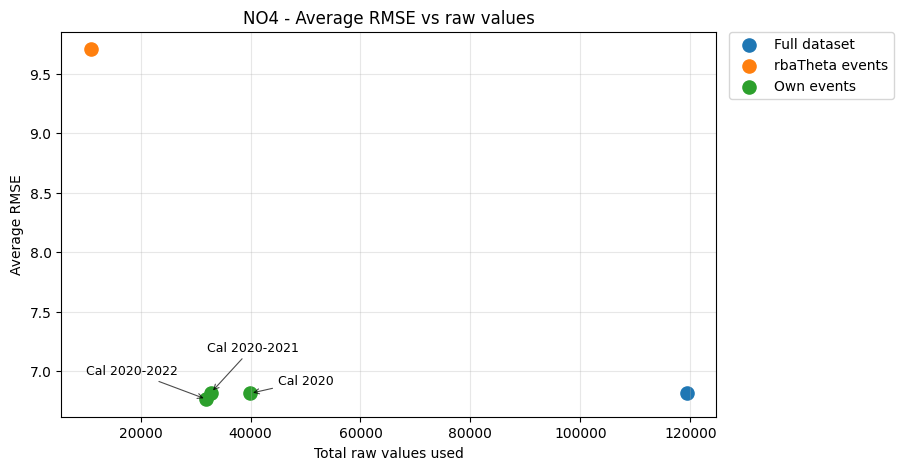

In [ ]:

# PLOTS FROM avg_by_calibration_table
# Average across models, keeping zones separated
# ============================================================

import matplotlib.pyplot as plt

plots_dir = tables_dir.parent / "summary_plots_average_models"
plots_dir.mkdir(parents=True, exist_ok=True)

plot_df = avg_by_calibration_table.copy()

plot_df = plot_df.rename(columns={
    "RMSE_mean": "Average RMSE",
    "Raw_values_used_pct": "Raw values used (%)",
    "Raw_value_reduction_pct": "Raw value reduction (%)",
})

# Keep only one repeated point for full_dataset and rbatheta_events per zone
fixed = plot_df[plot_df["Dataset"].isin(["full_dataset", "rbatheta_events"])]
fixed = fixed.drop_duplicates(subset=["Zone", "Dataset"])

own = plot_df[plot_df["Dataset"] == "own_events"]

plot_df = pd.concat([fixed, own], ignore_index=True)

# Colors for each dataset
dataset_colors = {
    "full_dataset": "tab:blue",
    "rbatheta_events": "tab:orange",
    "own_events": "tab:green",
}

dataset_names = {
    "full_dataset": "Full dataset",
    "rbatheta_events": "rbaTheta events",
    "own_events": "Own events",
}

# ------------------------------------------------------------
# Manual annotation positions
# Change these values to move the labels
# Format: (x_position, y_position)
# ------------------------------------------------------------

annotation_positions = {
    "NO2": {
        "cal_2020": (30000, 18.405),
        "cal_2020_2021": (27000, 18.505),
        "cal_2020_2022": (18000, 18.575),
    },
    "NO4": {
        "cal_2020": (45000, 6.92),
        "cal_2020_2021": (32000, 7.2),
        "cal_2020_2022": (10000, 7.0),
    }
}

# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def plot_metric_vs_raw_values(zone, metric):
    df_zone = plot_df[plot_df["Zone"] == zone].copy()
    df_zone = df_zone.sort_values("total_raw_values")

    # Wider figure so the plotting area does not become smaller
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot each dataset with same marker shape, different color
    for dataset in ["full_dataset", "rbatheta_events", "own_events"]:
        df_dataset = df_zone[df_zone["Dataset"] == dataset]

        ax.scatter(
            df_dataset["total_raw_values"],
            df_dataset[metric],
            s=90,
            color=dataset_colors[dataset],
            marker="o",
            label=dataset_names[dataset],
        )

    # Annotate only own_events calibrations with arrows
    df_own = df_zone[df_zone["Dataset"] == "own_events"]

    for _, row in df_own.iterrows():

        calibration = row["Calibration"]

        calibration_label = (
            calibration
            .replace("cal_", "Cal ")
            .replace("_", "-")
        )

        x_point = row["total_raw_values"]
        y_point = row[metric]

        # Use manual text position if available
        if zone in annotation_positions and calibration in annotation_positions[zone]:
            x_text, y_text = annotation_positions[zone][calibration]
        else:
            x_text, y_text = x_point + 3000, y_point

        ax.annotate(
            calibration_label,
            xy=(x_point, y_point),
            xytext=(x_text, y_text),
            textcoords="data",
            ha="left",
            va="center",
            fontsize=9,
            arrowprops=dict(
                arrowstyle="->",
                lw=0.8,
                alpha=0.7,
                color="black",
            )
        )

    ax.set_title(f"{zone} - {metric} vs raw values")
    ax.set_xlabel("Total raw values used")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    # Reserve space at the right for the legend
    fig.subplots_adjust(right=0.78)

    # Legend outside
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0
    )

    filename = f"{zone}_{metric.replace(' ', '_')}_vs_raw_values.png"
    output_path = plots_dir / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print("Saved:", output_path)

    plt.show()

# ------------------------------------------------------------
# Generate plots
# ------------------------------------------------------------

for zone in ["NO2", "NO4"]:
    plot_metric_vs_raw_values(zone, "Average RMSE")